# Chapter 6 Interactive Instructor Notebook: Linear Transformations

**Course:** MATH 3260 — Linear Algebra  
**Sections:** 6.1–6.6  
**Audience:** Instructor version

This reworked notebook develops linear transformations from four mutually reinforcing viewpoints:

$$
\text{mapping rule}
\longleftrightarrow
\text{matrix}
\longleftrightarrow
\text{kernel and range}
\longleftrightarrow
\text{geometry}.
$$

The chapter emphasizes **why** the major results work, not only how to compute them. Definitions are followed by conceptual interpretation, proofs, detailed examples, computational verification, classroom questions, and hidden instructor solutions.

> **Design rule:** introduce the vector-space meaning first, derive the matrix procedure from that meaning, and use computation to verify or visualize rather than replace the mathematics.

> **How to Use This Notebook in Class**
>
> Run the notebook from top to bottom before class. Pause at each **Classroom Question**, **Classroom Check**, or worksheet problem and allow students time to work before clicking **Reveal answer**.
>
> Click the same button again to hide the answer. Complete solutions are stored in a hidden instructor answer bank rather than printed openly while scrolling.
>
> Display mathematics uses ordinary Markdown/LaTeX rather than raw HTML callout containers so equations render reliably in JupyterLab, classic Jupyter Notebook, VS Code, and Google Colab.

## Chapter map

1. **Section 6.1:** Introduction to Linear Transformations
2. **Section 6.2:** Kernel and Range of a Linear Transformation
3. **Section 6.3:** Matrices for Linear Transformations
4. **Section 6.4:** Transition Matrices and Similarity
5. **Section 6.5:** Applications of Linear Transformations
6. **Section 6.6:** Kronecker Product and Structured Matrices

Each section ends with a terminology table and an in-class worksheet. Instructor solutions remain hidden until you choose to reveal them.

In [1]:
# Local environment check, imports, reveal helper, and Chapter 6 utilities.
import importlib.util
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Math, Markdown, HTML
from mpl_toolkits.mplot3d import Axes3D

required_packages = ["numpy", "sympy", "matplotlib"]
missing_packages = [name for name in required_packages if importlib.util.find_spec(name) is None]
if missing_packages:
    raise ModuleNotFoundError(
        "Missing packages: " + ", ".join(missing_packages) +
        ". Install them before running this notebook."
    )

try:
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False
    print("ipywidgets is unavailable. A dependency-free HTML reveal button will be used instead.")

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    pass

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

sp.init_printing()
np.set_printoptions(precision=4, suppress=True)


def reveal_answer(answer_markdown, button_text="Reveal answer"):
    """Create a click-to-reveal / click-to-hide answer button."""
    if not WIDGETS_AVAILABLE:
        import uuid
        try:
            import mistune
            answer_html = mistune.html(answer_markdown)
        except Exception:
            import html as _html
            answer_html = "<pre>" + _html.escape(answer_markdown) + "</pre>"
        box_id = "answer_" + uuid.uuid4().hex
        btn_id = "button_" + uuid.uuid4().hex
        safe_label = button_text.replace('"', '&quot;')
        html_block = f"""
        <div style='margin:8px 0 14px 0;'>
          <button id='{btn_id}'
            style='padding:6px 12px;border:1px solid #4b87b9;border-radius:5px;background:#eef6ff;cursor:pointer;font-weight:600;'
            onclick="var box=document.getElementById('{box_id}'); var btn=document.getElementById('{btn_id}');
                     if(box.style.display==='none'){{box.style.display='block';btn.innerText='Hide answer';
                     if(window.MathJax && MathJax.typesetPromise){{MathJax.typesetPromise([box]);}}}}
                     else{{box.style.display='none';btn.innerText='{safe_label}';}}">
            {safe_label}
          </button>
          <div id='{box_id}' style='display:none;margin-top:10px;padding:10px 12px;border-left:4px solid #4b87b9;background:#fafcff;'>
            {answer_html}
          </div>
        </div>
        """
        display(HTML(html_block))
        return None

    button = widgets.ToggleButton(
        value=False,
        description=button_text,
        icon="eye",
        button_style="info",
        layout=widgets.Layout(width="190px")
    )
    out = widgets.Output()

    def _toggle(change):
        out.clear_output(wait=True)
        if change["new"]:
            button.description = "Hide answer"
            button.icon = "eye-slash"
            with out:
                display(Markdown(answer_markdown))
        else:
            button.description = button_text
            button.icon = "eye"

    button.observe(_toggle, names="value")
    display(widgets.VBox([button, out]))
    return button


def show_matrix(M, label=None):
    M = sp.Matrix(M)
    if label:
        display(Math(rf"{label}={sp.latex(M)}"))
    else:
        display(M)
    return M


def show_vector(v, label=None):
    v = sp.Matrix(v)
    if label:
        display(Math(rf"{label}={sp.latex(v)}"))
    else:
        display(v)
    return v


def show_exact(expr, label):
    value = sp.simplify(expr)
    display(Math(rf"{label}={sp.latex(value)}"))
    return value


def plot_linear_map_2d(A, points, title="Planar linear transformation"):
    A = np.asarray(A, dtype=float)
    pts = np.asarray(points, dtype=float)
    transformed = (A @ pts.T).T
    closed = np.vstack([pts, pts[0]])
    closed_t = np.vstack([transformed, transformed[0]])
    fig, ax = plt.subplots(figsize=(6.5, 6.0))
    ax.plot(closed[:,0], closed[:,1], marker='o', label='original')
    ax.plot(closed_t[:,0], closed_t[:,1], marker='o', label='transformed')
    ax.axhline(0, linewidth=.8)
    ax.axvline(0, linewidth=.8)
    ax.grid(alpha=.3)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.legend()
    plt.show()


def plot_vectors_3d(vectors, labels, title='Vectors in space'):
    fig = plt.figure(figsize=(7,6))
    ax = fig.add_subplot(111, projection='3d')
    maxval = max(max(abs(float(x)) for x in v) for v in vectors) + 1
    for v, label in zip(vectors, labels):
        ax.quiver(0,0,0,float(v[0]),float(v[1]),float(v[2]),arrow_length_ratio=.08)
        ax.text(float(v[0]),float(v[1]),float(v[2]),f'  {label}')
    ax.set_xlim(-maxval,maxval)
    ax.set_ylim(-maxval,maxval)
    ax.set_zlim(-maxval,maxval)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.set_title(title)
    plt.show()

In [2]:
CH6_ANSWERS = {'6.1-zero': 'Because linearity preserves scalar multiplication,\n'
             '\n'
             '$$\n'
             'T(\\mathbf0)=T(0\\mathbf v)=0T(\\mathbf v)=\\mathbf0.\n'
             '$$\n'
             '\n'
             'Equivalently, additivity gives\n'
             '\n'
             '$$\n'
             'T(\\mathbf0)=T(\\mathbf0+\\mathbf0)=T(\\mathbf0)+T(\\mathbf0),\n'
             '$$\n'
             '\n'
             'so subtracting $T(\\mathbf0)$ from both sides yields $T(\\mathbf0)=\\mathbf0$. This gives a fast '
             'necessary test for linearity.',
 '6.1-basis': 'If $B=\\{\\mathbf v_1,\\ldots,\\mathbf v_n\\}$ is a basis, every $\\mathbf v\\in V$ has a unique '
              'representation\n'
              '\n'
              '$$\n'
              '\\mathbf v=c_1\\mathbf v_1+\\cdots+c_n\\mathbf v_n.\n'
              '$$\n'
              '\n'
              'Linearity then forces\n'
              '\n'
              '$$\n'
              'T(\\mathbf v)=c_1T(\\mathbf v_1)+\\cdots+c_nT(\\mathbf v_n).\n'
              '$$\n'
              '\n'
              'Therefore, once the images of the basis vectors are known, no freedom remains in the value of $T$ on '
              'any other vector.',
 '6.1-dim': 'An $m\\times n$ matrix has $n$ columns, so it multiplies vectors in $\\mathbb R^n$. Its product has $m$ '
            'entries, so the output lies in $\\mathbb R^m$. Thus\n'
            '\n'
            '$$\n'
            'A\\in\\mathbb R^{m\\times n}\n'
            '\\ \\Longrightarrow\\ \n'
            'T_A:\\mathbb R^n\\to\\mathbb R^m.\n'
            '$$',
 '6.1-affine': 'The translation term breaks linearity. For\n'
               '\n'
               '$$\n'
               'F(\\mathbf x)=A\\mathbf x+\\mathbf b,\n'
               '$$\n'
               '\n'
               'we have $F(\\mathbf0)=\\mathbf b$. A linear transformation must send $\\mathbf0$ to $\\mathbf0$, so '
               '$F$ can be linear only when $\\mathbf b=\\mathbf0$. Such maps with $\\mathbf b\\ne\\mathbf0$ are '
               'affine transformations, not linear transformations.',
 '6.1-w1': 'Substitute $(4,-2)$:\n\n$$\nT(4,-2)=(2(4)-(-2),4+3(-2))=(10,-2).\n$$',
 '6.1-w2': 'Solve\n'
           '\n'
           '$$\n'
           '2x-y=5,\n'
           '$$\n'
           '\n'
           '$$\n'
           'x+3y=6.\n'
           '$$\n'
           '\n'
           'From the first equation, $y=2x-5$. Substitution gives $x+3(2x-5)=6$, hence $7x=21$, so $x=3$ and $y=1$. '
           'The preimage is $\\{(3,1)\\}$.',
 '6.1-w3': 'For $T(x,y)=(x-2y,3x+y)$, direct substitution gives\n'
           '\n'
           '$$\n'
           'T(\\mathbf u+\\mathbf v)=T(\\mathbf u)+T(\\mathbf v)\n'
           '$$\n'
           '\n'
           'and\n'
           '\n'
           '$$\n'
           'T(c\\mathbf u)=cT(\\mathbf u).\n'
           '$$\n'
           '\n'
           'Hence $T$ is linear. Equivalently,\n'
           '\n'
           '$$\n'
           'T(\\mathbf x)=\n'
           '\\begin{bmatrix}\n'
           '1&-2\\\\\n'
           '3&1\n'
           '\\end{bmatrix}\\mathbf x,\n'
           '$$\n'
           '\n'
           'and every matrix-defined mapping is linear.',
 '6.1-w4': '$F(0,0)=(1,0)\\ne(0,0)$. Since every linear transformation sends the zero vector to the zero vector, $F$ '
           'is not linear.',
 '6.1-w5': 'Because\n'
           '\n'
           '$$\n'
           '(1,-2,3)=\\mathbf e_1-2\\mathbf e_2+3\\mathbf e_3,\n'
           '$$\n'
           '\n'
           'linearity gives\n'
           '\n'
           '$$\n'
           'T(1,-2,3)=T(\\mathbf e_1)-2T(\\mathbf e_2)+3T(\\mathbf e_3).\n'
           '$$\n'
           '\n'
           'Therefore\n'
           '\n'
           '$$\n'
           '(9,1)-2(20,-3)+3(21,4)=(32,19).\n'
           '$$',
 '6.1-w6': 'For $p(x)=3-2x+5x^2-x^3$,\n'
           '\n'
           '$$\n'
           "p'(x)=-2+10x-3x^2.\n"
           '$$\n'
           '\n'
           'Also,\n'
           '\n'
           '$$\n'
           '\\int_0^1(1+x)\\,dx\n'
           '=\\left[x+\\frac{x^2}{2}\\right]_0^1\n'
           '=\\frac32.\n'
           '$$',
 '6.2-ker-sub': 'To prove $\\ker(T)$ is a subspace of $V$, use the subspace test. First, $T(\\mathbf0)=\\mathbf0$, so '
                '$\\mathbf0\\in\\ker(T)$. If $\\mathbf u,\\mathbf v\\in\\ker(T)$, then\n'
                '\n'
                '$$\n'
                'T(\\mathbf u+\\mathbf v)=T(\\mathbf u)+T(\\mathbf v)=\\mathbf0+\\mathbf0=\\mathbf0,\n'
                '$$\n'
                '\n'
                'so $\\mathbf u+\\mathbf v\\in\\ker(T)$. If $c$ is a scalar,\n'
                '\n'
                '$$\n'
                'T(c\\mathbf u)=cT(\\mathbf u)=c\\mathbf0=\\mathbf0,\n'
                '$$\n'
                '\n'
                'so $c\\mathbf u\\in\\ker(T)$. Therefore $\\ker(T)$ is a subspace of the domain.',
 '6.2-range-sub': 'The zero vector belongs to the range because $T(\\mathbf0)=\\mathbf0$. If $\\mathbf y_1=T(\\mathbf '
                  'v_1)$ and $\\mathbf y_2=T(\\mathbf v_2)$ are in the range, then\n'
                  '\n'
                  '$$\n'
                  '\\mathbf y_1+\\mathbf y_2=T(\\mathbf v_1)+T(\\mathbf v_2)=T(\\mathbf v_1+\\mathbf v_2),\n'
                  '$$\n'
                  '\n'
                  'so the sum is in the range. Also,\n'
                  '\n'
                  '$$\n'
                  'c\\mathbf y_1=cT(\\mathbf v_1)=T(c\\mathbf v_1),\n'
                  '$$\n'
                  '\n'
                  'so scalar multiples remain in the range. Hence $\\operatorname{range}(T)$ is a subspace of the '
                  'codomain.',
 '6.2-info': 'Vectors in the kernel become indistinguishable after transformation because they are all sent to '
             '$\\mathbf0$. More generally, if $\\mathbf u-\\mathbf v\\in\\ker(T)$, then\n'
             '\n'
             '$$\n'
             'T(\\mathbf u)-T(\\mathbf v)=T(\\mathbf u-\\mathbf v)=\\mathbf0,\n'
             '$$\n'
             '\n'
             'so $T(\\mathbf u)=T(\\mathbf v)$. Thus the kernel records directions that the transformation loses.',
 '6.2-rn': 'Let $\\{\\mathbf k_1,\\ldots,\\mathbf k_p\\}$ be a basis for $\\ker(T)$ and extend it to a basis\n'
           '\n'
           '$$\n'
           '\\{\\mathbf k_1,\\ldots,\\mathbf k_p,\\mathbf u_1,\\ldots,\\mathbf u_r\\}\n'
           '$$\n'
           '\n'
           'for $V$. One proves that $\\{T(\\mathbf u_1),\\ldots,T(\\mathbf u_r)\\}$ is a basis for '
           '$\\operatorname{range}(T)$. Therefore $p=\\operatorname{nullity}(T)$, $r=\\operatorname{rank}(T)$, and '
           'because the full basis of $V$ has $p+r$ vectors,\n'
           '\n'
           '$$\n'
           '\\operatorname{rank}(T)+\\operatorname{nullity}(T)=\\dim(V).\n'
           '$$',
 '6.2-one': 'If $T$ is one-to-one and $\\mathbf v\\in\\ker(T)$, then $T(\\mathbf v)=\\mathbf0=T(\\mathbf0)$. '
            'One-to-one implies $\\mathbf v=\\mathbf0$, so $\\ker(T)=\\{\\mathbf0\\}$. Conversely, if '
            '$\\ker(T)=\\{\\mathbf0\\}$ and $T(\\mathbf u)=T(\\mathbf v)$, then\n'
            '\n'
            '$$\n'
            'T(\\mathbf u-\\mathbf v)=\\mathbf0.\n'
            '$$\n'
            '\n'
            'Thus $\\mathbf u-\\mathbf v\\in\\ker(T)$, so $\\mathbf u=\\mathbf v$. Hence $T$ is one-to-one.',
 '6.2-dim': 'If $\\dim(V)=\\dim(W)=n$, then rank-nullity gives\n'
            '\n'
            '$$\n'
            '\\operatorname{rank}(T)+\\operatorname{nullity}(T)=n.\n'
            '$$\n'
            '\n'
            'One-to-one means nullity $0$, so rank $n$, which equals $\\dim(W)$; hence $T$ is onto. Conversely, onto '
            'means rank $n$, so nullity $0$; hence $T$ is one-to-one.',
 '6.2-w1': 'For $T(x,y,z)=(x,y,0)$, the equation $T(x,y,z)=\\mathbf0$ gives $x=y=0$ with $z$ free. Thus\n'
           '\n'
           '$$\n'
           '\\ker(T)=\\operatorname{span}\\{(0,0,1)\\}.\n'
           '$$',
 '6.2-w2': 'The range is the $xy$-plane:\n'
           '\n'
           '$$\n'
           '\\operatorname{range}(T)=\\{(x,y,0):x,y\\in\\mathbb R\\}\n'
           '=\\operatorname{span}\\{(1,0,0),(0,1,0)\\}.\n'
           '$$',
 '6.2-w3': 'For the matrix in the worked example, there are three pivot columns, so $\\operatorname{rank}(T)=3$. The '
           'domain is $\\mathbb R^4$, hence rank-nullity gives\n'
           '\n'
           '$$\n'
           '\\operatorname{nullity}(T)=4-3=1.\n'
           '$$',
 '6.2-w4': 'The transformation is not one-to-one because its nullity is $1$, so the kernel contains nonzero vectors. '
           'It is onto $\\mathbb R^3$ because its rank is $3=\\dim(\\mathbb R^3)$.',
 '6.2-w5': 'If $T:\\mathbb R^5\\to\\mathbb R^3$ has rank $3$, then it is onto because the range has the same dimension '
           'as the codomain. Rank-nullity gives nullity $5-3=2$, so it is not one-to-one.',
 '6.2-w6': '$P_3$ has dimension $4$ and $\\mathbb R^4$ has dimension $4$. Any two finite-dimensional real vector '
           'spaces of the same dimension are isomorphic. For example,\n'
           '\n'
           '$$\n'
           'a+bx+cx^2+dx^3\\mapsto(a,b,c,d)\n'
           '$$\n'
           '\n'
           'is a linear bijection from $P_3$ to $\\mathbb R^4$.',
 '6.3-cols': 'Every vector $\\mathbf x\\in\\mathbb R^n$ can be written as\n'
             '\n'
             '$$\n'
             '\\mathbf x=x_1\\mathbf e_1+\\cdots+x_n\\mathbf e_n.\n'
             '$$\n'
             '\n'
             'Linearity gives\n'
             '\n'
             '$$\n'
             'T(\\mathbf x)=x_1T(\\mathbf e_1)+\\cdots+x_nT(\\mathbf e_n).\n'
             '$$\n'
             '\n'
             'Matrix multiplication by\n'
             '\n'
             '$$\n'
             'A=[T(\\mathbf e_1)\\ \\cdots\\ T(\\mathbf e_n)]\n'
             '$$\n'
             '\n'
             'produces exactly this same linear combination of columns. Therefore $T(\\mathbf x)=A\\mathbf x$.',
 '6.3-order': 'If $T_1$ is applied first and $T_2$ second, then\n'
              '\n'
              '$$\n'
              '(T_2\\circ T_1)(\\mathbf x)=T_2(T_1(\\mathbf x))=A_2(A_1\\mathbf x)=(A_2A_1)\\mathbf x.\n'
              '$$\n'
              '\n'
              'The rightmost matrix acts first. This is the same reverse-application order seen in ordinary function '
              'composition.',
 '6.3-inv': 'If $T(\\mathbf x)=A\\mathbf x$ and $A$ is invertible, define $S(\\mathbf y)=A^{-1}\\mathbf y$. Then\n'
            '\n'
            '$$\n'
            'S(T(\\mathbf x))=A^{-1}A\\mathbf x=\\mathbf x\n'
            '$$\n'
            '\n'
            'and\n'
            '\n'
            '$$\n'
            'T(S(\\mathbf y))=AA^{-1}\\mathbf y=\\mathbf y.\n'
            '$$\n'
            '\n'
            'Thus $S=T^{-1}$. Conversely, if a linear inverse exists, its standard matrix $B$ satisfies $BA=AB=I$, so '
            '$A$ is invertible and $B=A^{-1}$.',
 '6.3-nonstd': 'If $B=\\{\\mathbf v_1,\\ldots,\\mathbf v_n\\}$ is the domain basis, then the $j$th coordinate vector '
               '$\\mathbf e_j$ represents $\\mathbf v_j$ in $B$-coordinates. Therefore the $j$th column of the '
               'transformation matrix must be the output coordinate vector $[T(\\mathbf v_j)]_C$. This guarantees\n'
               '\n'
               '$$\n'
               '[T(\\mathbf v)]_C=[T]_{C\\leftarrow B}[\\mathbf v]_B.\n'
               '$$',
 '6.3-w1': 'Compute images of the standard basis:\n'
           '\n'
           '$$\n'
           'T(\\mathbf e_1)=(1,2),\n'
           '$$\n'
           '\n'
           '$$\n'
           'T(\\mathbf e_2)=(-2,1),\n'
           '$$\n'
           '\n'
           '$$\n'
           'T(\\mathbf e_3)=(0,0).\n'
           '$$\n'
           '\n'
           'Thus\n'
           '\n'
           '$$\n'
           'A=\\begin{bmatrix}1&-2&0\\\\2&1&0\\end{bmatrix}.\n'
           '$$',
 '6.3-w2': 'If $A_1$ and $A_2$ are the standard matrices, then the standard matrix for $T_2\\circ T_1$ is $A_2A_1$, '
           'because $T_1$ acts first and its output becomes the input to $T_2$.',
 '6.3-w3': 'For\n'
           '\n'
           '$$\n'
           'A=\\begin{bmatrix}2&1\\\\1&1\\end{bmatrix},\n'
           '$$\n'
           '\n'
           '$\\det(A)=1$, so $A$ is invertible and\n'
           '\n'
           '$$\n'
           'A^{-1}=\\begin{bmatrix}1&-1\\\\-1&2\\end{bmatrix}.\n'
           '$$\n'
           '\n'
           'Therefore $T^{-1}(\\mathbf y)=A^{-1}\\mathbf y$.',
 '6.3-w4': 'Compute $T(\\mathbf v_1)$ and $T(\\mathbf v_2)$, then express each result in the codomain basis $C$. Those '
           'coordinate vectors become columns. This is the systematic nonstandard-basis construction.',
 '6.3-w5': 'For $D:P_2\\to P_1$, with domain basis $\\{1,x,x^2\\}$ and codomain basis $\\{1,x\\}$,\n'
           '\n'
           '$$\n'
           'D(1)=0,\n'
           '$$\n'
           '\n'
           '$$\n'
           'D(x)=1,\n'
           '$$\n'
           '\n'
           '$$\n'
           'D(x^2)=2x.\n'
           '$$\n'
           '\n'
           'Thus\n'
           '\n'
           '$$\n'
           '[D]=\\begin{bmatrix}0&1&0\\\\0&0&2\\end{bmatrix}.\n'
           '$$',
 '6.3-w6': 'For any vector $\\mathbf x$, first applying $T$ and then $T^{-1}$ returns $\\mathbf x$. At the matrix '
           'level,\n'
           '\n'
           '$$\n'
           'A^{-1}A\\mathbf x=I\\mathbf x=\\mathbf x.\n'
           '$$\n'
           '\n'
           'This is the matrix expression of inverse transformations undoing each other.',
 '6.4-arrow': 'The notation is read as **destination $\\leftarrow$ source**. Thus $P_{C\\leftarrow B}$ accepts '
              '$B$-coordinates and outputs $C$-coordinates:\n'
              '\n'
              '$$\n'
              '[\\mathbf x]_C=P_{C\\leftarrow B}[\\mathbf x]_B.\n'
              '$$\n'
              '\n'
              'The vector $\\mathbf x$ itself does not change; only its coordinate description changes.',
 '6.4-columns': 'Because $[\\mathbf b_j]_B=\\mathbf e_j$, applying the coordinate-conversion matrix gives\n'
                '\n'
                '$$\n'
                'P_{C\\leftarrow B}\\mathbf e_j=[\\mathbf b_j]_C.\n'
                '$$\n'
                '\n'
                'Multiplying by $\\mathbf e_j$ selects column $j$, so column $j$ of $P_{C\\leftarrow B}$ is exactly '
                '$[\\mathbf b_j]_C$.',
 '6.4-gj': 'Row operations correspond to left multiplication by an invertible matrix $E$. Reducing the left block '
           '$M_C$ to $I$ means\n'
           '\n'
           '$$\n'
           'EM_C=I,\n'
           '$$\n'
           '\n'
           'so $E=M_C^{-1}$. The same row operations transform the right block to\n'
           '\n'
           '$$\n'
           'EM_B=M_C^{-1}M_B=P_{C\\leftarrow B}.\n'
           '$$\n'
           '\n'
           'Hence\n'
           '\n'
           '$$\n'
           '[M_C\\mid M_B]\\longrightarrow[I\\mid P_{C\\leftarrow B}].\n'
           '$$',
 '6.4-sim': 'Let $A_B$ represent $T$ in basis $B$ and $A_C$ represent $T$ in basis $C$. Starting with $[\\mathbf '
            'x]_C$, first convert to $B$-coordinates, apply $A_B$, then convert the output back to $C$-coordinates:\n'
            '\n'
            '$$\n'
            '[T(\\mathbf x)]_C=P_{C\\leftarrow B}A_BP_{B\\leftarrow C}[\\mathbf x]_C.\n'
            '$$\n'
            '\n'
            'Therefore\n'
            '\n'
            '$$\n'
            'A_C=P_{C\\leftarrow B}A_BP_{B\\leftarrow C}.\n'
            '$$\n'
            '\n'
            'Since the two transition matrices are inverses, the two representation matrices are similar.',
 '6.4-invar': "If $A'=P^{-1}AP$, then\n"
              '\n'
              '$$\n'
              "\\det(A')=\\det(P^{-1})\\det(A)\\det(P)=\\det(A).\n"
              '$$\n'
              '\n'
              'Also, multiplication by invertible matrices does not change rank, so '
              "$\\operatorname{rank}(A')=\\operatorname{rank}(A)$. Trace is also preserved under similarity because "
              '$\\operatorname{tr}(XY)=\\operatorname{tr}(YX)$:\n'
              '\n'
              '$$\n'
              '\\operatorname{tr}(P^{-1}AP)=\\operatorname{tr}(APP^{-1})=\\operatorname{tr}(A).\n'
              '$$',
 '6.4-w1': 'With\n'
           '\n'
           '$$\n'
           'M_B=\\begin{bmatrix}1&1\\\\1&-1\\end{bmatrix},\n'
           '$$\n'
           '\n'
           'and\n'
           '\n'
           '$$\n'
           'M_C=\\begin{bmatrix}1&1\\\\0&1\\end{bmatrix},\n'
           '$$\n'
           '\n'
           'we have\n'
           '\n'
           '$$\n'
           'P_{C\\leftarrow B}=M_C^{-1}M_B\n'
           '=\\begin{bmatrix}0&2\\\\1&-1\\end{bmatrix}.\n'
           '$$',
 '6.4-w2': 'Multiply:\n'
           '\n'
           '$$\n'
           '[\\mathbf x]_C=P_{C\\leftarrow B}[\\mathbf x]_B\n'
           '=\\begin{bmatrix}0&2\\\\1&-1\\end{bmatrix}\n'
           '\\begin{bmatrix}3\\\\2\\end{bmatrix}\n'
           '=\\begin{bmatrix}4\\\\1\\end{bmatrix}.\n'
           '$$',
 '6.4-w3': 'For\n'
           '\n'
           '$$\n'
           'A=\\begin{bmatrix}2&1\\\\1&2\\end{bmatrix},\n'
           '$$\n'
           '\n'
           'and\n'
           '\n'
           '$$\n'
           'P=\\begin{bmatrix}1&1\\\\1&-1\\end{bmatrix},\n'
           '$$\n'
           '\n'
           'we have\n'
           '\n'
           '$$\n'
           'P^{-1}=\\frac12\\begin{bmatrix}1&1\\\\1&-1\\end{bmatrix}\n'
           '$$\n'
           '\n'
           'and\n'
           '\n'
           '$$\n'
           'P^{-1}AP=\\begin{bmatrix}3&0\\\\0&1\\end{bmatrix}.\n'
           '$$',
 '6.4-w4': 'For $A$, trace $=4$ and determinant $=3$. For the similar diagonal matrix, trace $=3+1=4$ and determinant '
           '$=3(1)=3$. This illustrates that trace and determinant do not depend on the basis used to represent the '
           'transformation.',
 '6.4-w5': 'If $A=PDP^{-1}$ with $D=\\operatorname{diag}(3,1)$, then\n'
           '\n'
           '$$\n'
           'A^5=PD^5P^{-1}.\n'
           '$$\n'
           '\n'
           'Since $D^5=\\operatorname{diag}(243,1)$,\n'
           '\n'
           '$$\n'
           'A^5=\\begin{bmatrix}122&121\\\\121&122\\end{bmatrix}.\n'
           '$$',
 '6.4-w6': 'Coordinates depend on which basis vector is listed first, second, and so on. Reordering a basis changes '
           'the coordinate columns and therefore changes the transition matrix. The underlying vector does not change, '
           'but its ordered coordinate representation does.',
 '6.5-basisimg': 'A matrix is determined by its columns, and column $j$ is the image of $\\mathbf e_j$. Therefore a '
                 'geometric rule can be converted into a matrix by asking where the transformation sends the standard '
                 'basis directions. For example, reflection across the $y$-axis sends $\\mathbf e_1$ to $-\\mathbf '
                 'e_1$ and $\\mathbf e_2$ to $\\mathbf e_2$, giving $\\begin{bmatrix}-1&0\\\\0&1\\end{bmatrix}$.',
 '6.5-shear': 'For a horizontal shear\n'
              '\n'
              '$$\n'
              'H(k)=\\begin{bmatrix}1&k\\\\0&1\\end{bmatrix},\n'
              '$$\n'
              '\n'
              '$\\det(H(k))=1$. Since absolute determinant is the planar area scale factor, every region keeps the '
              'same area even though its shape changes. Geometrically, parallel horizontal layers slide without '
              'changing base-height area.',
 '6.5-order': 'If a point is first transformed by $A$ and then by $B$, the final result is\n'
              '\n'
              '$$\n'
              'B(A\\mathbf x)=(BA)\\mathbf x.\n'
              '$$\n'
              '\n'
              'Thus the rightmost matrix acts first. In general $BA\\ne AB$, so reversing the order can produce a '
              'different geometric transformation.',
 '6.5-rot': 'The rotation matrix has orthonormal columns, so\n'
            '\n'
            '$$\n'
            'Q(\\theta)^TQ(\\theta)=I.\n'
            '$$\n'
            '\n'
            'Therefore\n'
            '\n'
            '$$\n'
            '\\|Q(\\theta)\\mathbf x\\|^2\n'
            '=\\mathbf x^TQ(\\theta)^TQ(\\theta)\\mathbf x\n'
            '=\\mathbf x^T\\mathbf x\n'
            '=\\|\\mathbf x\\|^2.\n'
            '$$\n'
            '\n'
            'Also $\\det(Q(\\theta))=1$, so the rotation preserves both lengths and orientation.',
 '6.5-w1': 'The first matrix sends $(x,y)$ to $(-x,y)$, so it reflects across the $y$-axis. The second sends $(x,y)$ '
           'to $(x+2y,y)$, so it is a horizontal shear with factor $2$.',
 '6.5-w2': 'Reflection across $y=x$ swaps coordinates. Thus $(3,-2)$ maps to $(-2,3)$.',
 '6.5-w3': 'With\n'
           '\n'
           '$$\n'
           'H(1/2)=\\begin{bmatrix}1&1/2\\\\0&1\\end{bmatrix},\n'
           '$$\n'
           '\n'
           'the vertices map as\n'
           '\n'
           '$$\n'
           '(0,0)\\mapsto(0,0),\n'
           '$$\n'
           '\n'
           '$$\n'
           '(4,0)\\mapsto(4,0),\n'
           '$$\n'
           '\n'
           '$$\n'
           '(0,2)\\mapsto(1,2).\n'
           '$$\n'
           '\n'
           'So the transformed triangle has vertices $(0,0)$, $(4,0)$, and $(1,2)$.',
 '6.5-w4': 'Using\n'
           '\n'
           '$$\n'
           'Q(30^\\circ)=\\begin{bmatrix}\\sqrt3/2&-1/2\\\\1/2&\\sqrt3/2\\end{bmatrix},\n'
           '$$\n'
           '\n'
           'we obtain\n'
           '\n'
           '$$\n'
           'Q(30^\\circ)\\begin{bmatrix}2\\\\0\\end{bmatrix}\n'
           '=\\begin{bmatrix}\\sqrt3\\\\1\\end{bmatrix}.\n'
           '$$',
 '6.5-w5': 'Horizontal stretch first means use\n'
           '\n'
           '$$\n'
           'S=\\begin{bmatrix}2&0\\\\0&1\\end{bmatrix}\n'
           '$$\n'
           '\n'
           'first, then\n'
           '\n'
           '$$\n'
           'Q=\\begin{bmatrix}0&-1\\\\1&0\\end{bmatrix}.\n'
           '$$\n'
           '\n'
           'The combined matrix is\n'
           '\n'
           '$$\n'
           'QS=\\begin{bmatrix}0&-1\\\\2&0\\end{bmatrix}.\n'
           '$$',
 '6.5-w6': 'A $90^\\circ$ counterclockwise rotation about the $z$-axis sends $(x,y,z)$ to $(-y,x,z)$. Therefore\n'
           '\n'
           '$$\n'
           '(1,2,3)\\mapsto(-2,1,3).\n'
           '$$',
 '6.6-check': 'If $A$ is $2\\times 3$ and $B$ is $4\\times 2$, then\n'
              '\n'
              '$$\n'
              'A\\otimes B\n'
              '$$\n'
              '\n'
              'has\n'
              '\n'
              '$$\n'
              '(2)(4)=8\n'
              '$$\n'
              '\n'
              'rows and\n'
              '\n'
              '$$\n'
              '(3)(2)=6\n'
              '$$\n'
              '\n'
              'columns. Therefore,\n'
              '\n'
              '$$\n'
              '\\boxed{A\\otimes B\\text{ is }8\\times6.}\n'
              '$$',
 '6.6-w1': 'Use the block definition:\n'
           '\n'
           '$$\n'
           'A\\otimes B\n'
           '=\n'
           '\\begin{bmatrix}\n'
           '1B&2B\\\\\n'
           '0B&-1B\n'
           '\\end{bmatrix}.\n'
           '$$\n'
           '\n'
           'Since\n'
           '\n'
           '$$\n'
           'B=\n'
           '\\begin{bmatrix}\n'
           '1&0\\\\\n'
           '3&2\n'
           '\\end{bmatrix},\n'
           '$$\n'
           '\n'
           'we obtain\n'
           '\n'
           '$$\n'
           '\\boxed{\n'
           'A\\otimes B=\n'
           '\\begin{bmatrix}\n'
           '1&0&2&0\\\\\n'
           '3&2&6&4\\\\\n'
           '0&0&-1&0\\\\\n'
           '0&0&-3&-2\n'
           '\\end{bmatrix}.\n'
           '}\n'
           '$$',
 '6.6-w2': 'The matrix $I_3\\otimes A$ places three copies of $A$ on the block diagonal:\n'
           '\n'
           '$$\n'
           '\\boxed{\n'
           'I_3\\otimes A=\n'
           '\\begin{bmatrix}\n'
           'A&0&0\\\\\n'
           '0&A&0\\\\\n'
           '0&0&A\n'
           '\\end{bmatrix}.\n'
           '}\n'
           '$$\n'
           '\n'
           'It represents the same linear action $A$ applied independently to three separate groups of variables.',
 '6.6-w3': 'Here\n'
           '\n'
           '$$\n'
           'A\\oplus B=\n'
           '\\begin{bmatrix}\n'
           'A&0\\\\\n'
           '0&B\n'
           '\\end{bmatrix}\n'
           '$$\n'
           '\n'
           'places $A$ and $B$ in separate diagonal blocks. By contrast,\n'
           '\n'
           '$$\n'
           'A\\otimes B\n'
           '$$\n'
           '\n'
           'replaces every entry $a_{ij}$ of $A$ by the block $a_{ij}B$. The direct sum combines two matrices side by '
           'side as independent blocks, while the Kronecker product builds a larger repeated block structure.'}

def reveal_answer_key(key, button_text='Reveal answer'):
    return reveal_answer(CH6_ANSWERS[key], button_text=button_text)


> **Notebook Workflow**
>
> The mathematical explanation comes first. Python cells are optional verification or visualization. Classroom questions and worksheets are followed by individual answer buttons so solutions remain hidden until you choose to reveal them.

> **Example Policy**
>
> Numerical and application examples are teaching models. Themes are used selectively, and fictional scenarios are identified as such. The purpose is to connect abstract linear-transformation ideas with concrete calculations without replacing the definitions, theorems, and proofs.

# Section 6.1 - Introduction to Linear Transformations

## Learning objectives

Students should be able to:

- distinguish domain, codomain, range, image, and preimage;
- test whether a mapping is linear;
- derive basic structural properties of linear transformations;
- use linearity to evaluate a transformation from its values on a basis;
- explain why a linear transformation is completely determined by its action on a basis;
- recognize matrix-defined mappings and common calculus operators as linear transformations.

## From Ordinary Functions to Transformations Between Vector Spaces

A **transformation** is a function that maps elements from one set to another.

In linear algebra, we are especially interested in transformations between **vector spaces**.

If

$$
T:V\to W,
$$

then:

* $V$ is the **domain**;
* $W$ is the **codomain**;
* for $\mathbf v\in V$, the element $T(\mathbf v)\in W$ is the **image** of $\mathbf v$;
* if

  $$
  T(\mathbf v)=\mathbf w,
  $$

  then $\mathbf v$ is a **preimage** of $\mathbf w$;
* the **range** is the set of all outputs that actually occur.

In symbols, the range is

$$
\operatorname{Range}(T)
=
\{T(\mathbf v):\mathbf v\in V\}.
$$

At first, many of our examples will use familiar coordinate vectors such as

$$
\begin{bmatrix}
x\\
y
\end{bmatrix}
\in\mathbb R^2.
$$

However, in linear algebra, the word **vector** has a broader meaning: a vector is any element of a vector space. Depending on the vector space, vectors may **be coordinate vectors, polynomials, matrices, functions, or other mathematical objects**.

Therefore, transformations between vector spaces are not limited to mappings involving coordinate vectors.

### Codomain versus Range

The **codomain** and the **range** are not automatically the same.

The codomain is the declared target space

$$
W,
$$

while the range consists only of the elements of $W$ that are actually reached by the transformation.

Thus,

$$
\operatorname{Range}(T)\subseteq W.
$$

The range equals the codomain only when every element of $W$ is the image of at least one element of $V$.


## Travel-profile example: image and preimage

Define

$$
T:\mathbb R^2\to\mathbb R^2,
$$

by

$$
T(x,y)=(2x-y,x+3y).
$$

For the fictional travel profile $(3,1)$,

$$
T(3,1)=(2(3)-1,3+3(1))=(5,6).
$$

Thus $(5,6)$ is the image of $(3,1)$.

To find the preimage of $(5,6)$, solve

$$
2x-y=5,
$$

$$
x+3y=6.
$$

From the first equation,

$$
y=2x-5.
$$

Substitute into the second:

$$
x+3(2x-5)=6,
$$

so

$$
7x=21,
$$

and therefore

$$
x=3,
$$

$$
y=1.
$$

For this transformation, the preimage of $(5,6)$ is the single vector $(3,1)$.

In [3]:
x, y = sp.symbols('x y')
sol = sp.solve([sp.Eq(2*x-y,5), sp.Eq(x+3*y,6)], [x,y], dict=True)
print(sol)

[{x: 3, y: 1}]


> **Definition: Linear Transformation**
>
> Let $V$ and $W$ be vector spaces. A mapping
>
> $$
> T:V\to W
> $$
>
> is a **linear transformation** if, for all $\mathbf u,\mathbf v\in V$ and every scalar $c$,
>
> $$
> \boxed{T(\mathbf u+\mathbf v)=T(\mathbf u)+T(\mathbf v)}
> $$
>
> and
>
> $$
> \boxed{T(c\mathbf u)=cT(\mathbf u)}.
> $$
>
> These two conditions say that $T$ respects the vector-space operations.

## Verifying linearity directly

Consider again

$$
T(x,y)=(2x-y,x+3y).
$$

Let

$$
\mathbf u=(u_1,u_2)
$$

and

$$
\mathbf v=(v_1,v_2).
$$

For additivity,

$$
T(\mathbf u+\mathbf v)
=T(u_1+v_1,u_2+v_2).
$$

Therefore,

$$
T(\mathbf u+\mathbf v)
=(2u_1+2v_1-u_2-v_2,u_1+v_1+3u_2+3v_2).
$$

Regrouping gives

$$
T(\mathbf u+\mathbf v)
=(2u_1-u_2,u_1+3u_2)
+(2v_1-v_2,v_1+3v_2),
$$

so

$$
T(\mathbf u+\mathbf v)=T(\mathbf u)+T(\mathbf v).
$$

For homogeneity,

$$
T(c\mathbf u)=T(cu_1,cu_2),
$$

which gives

$$
T(c\mathbf u)
=(2cu_1-cu_2,cu_1+3cu_2)
=cT(\mathbf u).
$$

Hence $T$ is linear.

## Properties that follow automatically from linearity

If $T:V\to W$ is linear, then

$$
T(\mathbf0)=\mathbf0,
$$

$$
T(-\mathbf v)=-T(\mathbf v),
$$

$$
T(\mathbf u-\mathbf v)=T(\mathbf u)-T(\mathbf v),
$$

and more generally,

$$
\boxed{
T(c_1\mathbf v_1+\cdots+c_k\mathbf v_k)
=c_1T(\mathbf v_1)+\cdots+c_kT(\mathbf v_k)
}.
$$

The last formula is one of the most important ideas in this chapter: a linear transformation preserves **every finite linear combination**.

### Proof that linear transformations preserve finite linear combinations

For two terms, the defining properties give

$$
T(c_1\mathbf v_1+c_2\mathbf v_2)
=T(c_1\mathbf v_1)+T(c_2\mathbf v_2)
=c_1T(\mathbf v_1)+c_2T(\mathbf v_2).
$$

Applying the same argument repeatedly gives

$$
T(c_1\mathbf v_1+\cdots+c_k\mathbf v_k)
=c_1T(\mathbf v_1)+\cdots+c_kT(\mathbf v_k).
$$

This is why basis representations are so powerful for linear transformations.

### Classroom Check: Why must $T(\mathbf0)=\mathbf0$?

Use either additivity or scalar multiplication to prove this fact from the definition of linearity.

In [4]:
reveal_answer_key('6.1-zero','Reveal proof')

ToggleButton(value=False, button_style='info', description='Reveal proof', icon='eye', layout=Layout(width='19…

## Fast nonlinearity test and affine contrast

Every linear transformation satisfies

$$
T(\mathbf0)=\mathbf0.
$$

Therefore, the mapping

$$
F(x,y)=(x+1,y)
$$

cannot be linear because

$$
F(0,0)=(1,0)\ne(0,0).
$$

More generally, a mapping of the form

$$
F(\mathbf x)=A\mathbf x+\mathbf b
$$

with $\mathbf b\ne\mathbf0$ is typically called an **affine transformation**. It can preserve lines and geometric structure while failing the linear-transformation zero-vector requirement.

### Classroom Check: Why does a translation term destroy linearity?

For

$$
F(\mathbf x)=A\mathbf x+\mathbf b,
$$

what happens when $\mathbf x=\mathbf0$?

In [5]:
reveal_answer_key('6.1-affine','Reveal explanation')

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## A transformation determined by basis images

Suppose a linear transformation

$$
T:\mathbb R^3\to\mathbb R^2
$$

satisfies

$$
T(\mathbf e_1)=(9,1),
$$

$$
T(\mathbf e_2)=(20,-3),
$$

$$
T(\mathbf e_3)=(21,4).
$$

Because

$$
(2,-1,3)=2\mathbf e_1-\mathbf e_2+3\mathbf e_3,
$$

linearity forces

$$
T(2,-1,3)
=2T(\mathbf e_1)-T(\mathbf e_2)+3T(\mathbf e_3).
$$

Therefore,

$$
T(2,-1,3)=2(9,1)-(20,-3)+3(21,4)=(61,17).
$$

> **Theorem: A linear transformation is determined by its values on a basis**
>
> Let
>
> $$
> B=\{\mathbf v_1,\ldots,\mathbf v_n\}
> $$
>
> be a basis for $V$. If $T:V\to W$ is linear, then knowing
>
> $$
> T(\mathbf v_1),\ldots,T(\mathbf v_n)
> $$
>
> determines $T(\mathbf v)$ for every $\mathbf v\in V$.

### Why?

Every vector $\mathbf v\in V$ has a unique basis representation

$$
\mathbf v=c_1\mathbf v_1+\cdots+c_n\mathbf v_n.
$$

Therefore,

$$
\boxed{
T(\mathbf v)=c_1T(\mathbf v_1)+\cdots+c_nT(\mathbf v_n)
}.
$$

So a linear transformation has no additional freedom once its action on a basis has been specified.

### Classroom Check: Why are basis images enough?

Explain why knowing $T$ on only a spanning set that is not a basis may involve redundant information, while knowing $T$ on a basis is sufficient and nonredundant.

In [6]:
reveal_answer_key('6.1-basis','Reveal explanation')

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## Matrix-defined transformations

Every $m\times n$ matrix $A$ defines a linear transformation

$$
T_A:\mathbb R^n\to\mathbb R^m
$$

by

$$
\boxed{T_A(\mathbf x)=A\mathbf x}.
$$

Why is it linear? Matrix multiplication distributes over vector addition and respects scalar multiplication:

$$
A(\mathbf u+\mathbf v)=A\mathbf u+A\mathbf v,
$$

$$
A(c\mathbf u)=cA\mathbf u.
$$

Thus every matrix gives a linear transformation.

## Matrix example and dimension interpretation

Let

$$
A=
\begin{bmatrix}
1&2\\
3&-1\\
0&4
\end{bmatrix}.
$$

Since $A$ is $3\times2$, it defines

$$
T:\mathbb R^2\to\mathbb R^3.
$$

For

$$
\mathbf v=
\begin{bmatrix}
2\\
-1
\end{bmatrix},
$$

we have

$$
T(\mathbf v)=A\mathbf v
=
\begin{bmatrix}
0\\
7\\
-4
\end{bmatrix}.
$$

In [7]:
A = sp.Matrix([[1,2],[3,-1],[0,4]])
v = sp.Matrix([2,-1])
show_matrix(A, 'A')
show_vector(A*v, r'T(\mathbf v)')
print('Matrix shape:', A.shape)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Matrix shape: (3, 2)


### Classroom Check: Where do the domain and codomain dimensions come from?

Why does an $m\times n$ matrix naturally define a transformation from $\mathbb R^n$ to $\mathbb R^m$?

In [8]:
reveal_answer_key('6.1-dim','Reveal explanation')

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## Calculus operators as linear transformations

Linear transformations are not limited to coordinate vectors.

For polynomials, differentiation gives

$$
D:P_3\to P_2,
$$

$$
D(p)=p'.
$$

If

$$
p(x)=4-3x+2x^2+x^3,
$$

then

$$
D(p)=-3+4x+3x^2.
$$

Differentiation is linear because

$$
D(p+q)=D(p)+D(q)
$$

and

$$
D(cp)=cD(p).
$$

Likewise, the definite-integral functional

$$
L(p)=\int_0^1p(x)\,dx
$$

maps polynomials to real numbers and is linear because definite integration preserves sums and scalar multiples.

## Definitions and terminology

| Term | Meaning |
|---|---|
| Transformation | Function between vector spaces. |
| Domain | Vector space containing the allowable inputs. |
| Codomain | Declared target vector space. |
| Image | Output $T(\mathbf v)$ of an input vector. |
| Preimage | Input vector mapped to a specified output. |
| Range | Set of all outputs actually attained. |
| Linear transformation | Mapping preserving vector addition and scalar multiplication. |
| Zero transformation | Linear transformation sending every vector to the zero vector. |
| Matrix transformation | Mapping of the form $T(\mathbf x)=A\mathbf x$. |
| Differential operator | Linear transformation sending a differentiable function to its derivative. |
| Affine transformation | Mapping of the form $A\mathbf x+\mathbf b$; generally not linear when $\mathbf b\ne\mathbf0$. |

## Section 6.1 worksheet

Work each problem before revealing the instructor solution.

### Problem 1

For $T(x,y)=(2x-y,x+3y)$, find $T(4,-2)$.

In [9]:
reveal_answer_key('6.1-w1','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 2

Find the preimage of $(5,6)$ under the transformation in Problem 1.

In [10]:
reveal_answer_key('6.1-w2','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 3

Verify that $T(x,y)=(x-2y,3x+y)$ is linear.

In [11]:
reveal_answer_key('6.1-w3','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 4

Explain why $F(x,y)=(x+1,y)$ is not linear.

In [12]:
reveal_answer_key('6.1-w4','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 5

Suppose $T(\mathbf e_1)=(9,1)$, $T(\mathbf e_2)=(20,-3)$, and $T(\mathbf e_3)=(21,4)$. Find $T(1,-2,3)$.

In [13]:
reveal_answer_key('6.1-w5','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 6

Find the derivative of $3-2x+5x^2-x^3$ and evaluate $\int_0^1(1+x)\,dx$.

In [14]:
reveal_answer_key('6.1-w6','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

# Section 6.2 - Kernel and Range of a Linear Transformation

## Learning objectives

Students should be able to:

- find and interpret the kernel of a linear transformation;
- prove that the kernel and range are subspaces;
- relate the kernel of $T(\mathbf x)=A\mathbf x$ to the null space of $A$;
- relate the range of a matrix transformation to the column space of $A$;
- find bases for kernel and range;
- compute rank and nullity and apply the rank-nullity theorem;
- determine whether a linear transformation is one-to-one or onto;
- explain finite-dimensional isomorphism through dimension.

## Two subspaces attached to every linear transformation

Let

$$
T:V\to W
$$

be linear.

The **kernel** records which inputs are sent to zero:

$$
\boxed{
\ker(T)=\{\mathbf v\in V:T(\mathbf v)=\mathbf0\}.
}
$$

The **range** records which outputs can actually be reached:

$$
\boxed{
\operatorname{range}(T)=\{T(\mathbf v):\mathbf v\in V\}.
}
$$

Notice where they live:

$$
\ker(T)\subseteq V,
$$

while

$$
\operatorname{range}(T)\subseteq W.
$$

> **Theorem: The kernel is a subspace of the domain**
>
> If $T:V\to W$ is linear, then
>
> $$
> \ker(T)
> $$
>
> is a subspace of $V$.

### Proof

First,

$$
T(\mathbf0)=\mathbf0,
$$

so

$$
\mathbf0\in\ker(T).
$$

If $\mathbf u,\mathbf v\in\ker(T)$, then

$$
T(\mathbf u)=\mathbf0
$$

and

$$
T(\mathbf v)=\mathbf0.
$$

Therefore,

$$
T(\mathbf u+\mathbf v)
=T(\mathbf u)+T(\mathbf v)
=\mathbf0,
$$

so $\mathbf u+\mathbf v\in\ker(T)$.

For a scalar $c$,

$$
T(c\mathbf u)=cT(\mathbf u)=\mathbf0,
$$

so $c\mathbf u\in\ker(T)$.

Thus the kernel satisfies the subspace test.

### Classroom Check: Which subspace test properties were used?

Identify the three ingredients in the proof that $\ker(T)$ is a subspace.

In [15]:
reveal_answer_key('6.2-ker-sub','Reveal proof summary')

ToggleButton(value=False, button_style='info', description='Reveal proof summary', icon='eye', layout=Layout(w…

> **Theorem: The range is a subspace of the codomain**
>
> If $T:V\to W$ is linear, then
>
> $$
> \operatorname{range}(T)
> $$
>
> is a subspace of $W$.

### Proof

The zero vector belongs to the range because

$$
T(\mathbf0)=\mathbf0.
$$

Suppose

$$
\mathbf y_1=T(\mathbf v_1)
$$

and

$$
\mathbf y_2=T(\mathbf v_2)
$$

are in the range. Then

$$
\mathbf y_1+\mathbf y_2
=T(\mathbf v_1)+T(\mathbf v_2)
=T(\mathbf v_1+\mathbf v_2),
$$

which is again in the range.

Similarly,

$$
c\mathbf y_1
=cT(\mathbf v_1)
=T(c\mathbf v_1),
$$

so scalar multiples remain in the range.

Therefore the range is a subspace of $W$.

### Classroom Check: Why is the range automatically closed under addition?

Start with two arbitrary range vectors and write each one as an image under $T$.

In [16]:
reveal_answer_key('6.2-range-sub','Reveal proof summary')

ToggleButton(value=False, button_style='info', description='Reveal proof summary', icon='eye', layout=Layout(w…

## Projection onto the $xy$-plane

Consider

$$
T:\mathbb R^3\to\mathbb R^3,
$$

$$
T(x,y,z)=(x,y,0).
$$

To find the kernel, solve

$$
T(x,y,z)=(0,0,0).
$$

This gives

$$
x=0,
$$

$$
y=0,
$$

while $z$ is free. Therefore,

$$
\ker(T)=\{(0,0,z):z\in\mathbb R\}
=\operatorname{span}\{(0,0,1)\}.
$$

The range is the $xy$-plane:

$$
\operatorname{range}(T)
=\{(x,y,0):x,y\in\mathbb R\}
=\operatorname{span}\{(1,0,0),(0,1,0)\}.
$$

Geometrically, the $z$-component is lost, so the $z$-axis forms the kernel.

### Classroom Question: Why can the kernel be viewed as lost information?

What happens if two input vectors differ by a vector in the kernel?

In [17]:
reveal_answer_key('6.2-info','Reveal explanation')

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## Matrix transformations: kernel = null space, range = column space

Suppose

$$
T(\mathbf x)=A\mathbf x.
$$

Then

$$
\mathbf x\in\ker(T)
$$

if and only if

$$
A\mathbf x=\mathbf0.
$$

Therefore,

$$
\boxed{\ker(T)=N(A)}.
$$

Also, every output has the form

$$
A\mathbf x
=x_1\mathbf a_1+\cdots+x_n\mathbf a_n,
$$

where $\mathbf a_1,\ldots,\mathbf a_n$ are the columns of $A$. Hence

$$
\boxed{\operatorname{range}(T)=\operatorname{Col}(A)}.
$$

This connects the transformation language directly to the fundamental subspaces from Chapter 4.

## Detailed rank-nullity example

Let

$$
T:\mathbb R^4\to\mathbb R^3
$$

be defined by

$$
T(\mathbf x)=A\mathbf x,
$$

where

$$
A=
\begin{bmatrix}
1&0&2&1\\
0&1&-1&2\\
1&1&0&1
\end{bmatrix}.
$$

Row reduction gives

$$
\begin{bmatrix}
1&0&2&1\\
0&1&-1&2\\
1&1&0&1
\end{bmatrix}
\longrightarrow
\begin{bmatrix}
1&0&2&1\\
0&1&-1&2\\
0&1&-2&0
\end{bmatrix}
\longrightarrow
\begin{bmatrix}
1&0&2&1\\
0&1&-1&2\\
0&0&-1&-2
\end{bmatrix}.
$$

There are three pivots, so

$$
\operatorname{rank}(T)=3.
$$

To find the kernel, solve $A\mathbf x=\mathbf0$:

$$
x_1+2x_3+x_4=0,
$$

$$
x_2-x_3+2x_4=0,
$$

$$
-x_3-2x_4=0.
$$

Let

$$
x_4=t.
$$

Then

$$
x_3=-2t,
$$

$$
x_2=-4t,
$$

$$
x_1=3t.
$$

Therefore,

$$
\mathbf x=t(3,-4,-2,1),
$$

so

$$
\ker(T)=\operatorname{span}\{(3,-4,-2,1)\}.
$$

Thus

$$
\operatorname{nullity}(T)=1.
$$

In [18]:
A = sp.Matrix([[1,0,2,1],[0,1,-1,2],[1,1,0,1]])
R, pivots = A.rref()
show_matrix(A,'A')
show_matrix(R,r'\operatorname{rref}(A)')
print('Pivot columns (0-based):', pivots)
print('Rank:', A.rank())
print('Nullspace basis:')
for v in A.nullspace():
    display(v)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Pivot columns (0-based): (0, 1, 2)
Rank: 3
Nullspace basis:


⎡3 ⎤
⎢  ⎥
⎢-4⎥
⎢  ⎥
⎢-2⎥
⎢  ⎥
⎣1 ⎦

> **Definition: Rank and Nullity of a Linear Transformation**
>
> For a linear transformation $T:V\to W$,
>
> $$
> \boxed{\operatorname{rank}(T)=\dim(\operatorname{range}(T))}
> $$
>
> and
>
> $$
> \boxed{\operatorname{nullity}(T)=\dim(\ker(T))}.
> $$

> **Rank-Nullity Theorem**
>
> Let $T:V\to W$ be linear and suppose $V$ is finite dimensional. Then
>
> $$
> \boxed{
> \operatorname{rank}(T)+\operatorname{nullity}(T)=\dim(V).
> }
> $$

For the example above,

$$
3+1=4,
$$

which equals

$$
\dim(\mathbb R^4).
$$

### Why does rank-nullity work? A basis proof

Suppose

$$
\{\mathbf k_1,\ldots,\mathbf k_p\}
$$

is a basis for $\ker(T)$.

Extend this kernel basis to a basis for the entire domain $V$:

$$
\{\mathbf k_1,\ldots,\mathbf k_p,\mathbf u_1,\ldots,\mathbf u_r\}.
$$

We claim that

$$
\{T(\mathbf u_1),\ldots,T(\mathbf u_r)\}
$$

is a basis for $\operatorname{range}(T)$.

**Spanning the range.** Any $\mathbf v\in V$ can be written as

$$
\mathbf v
=a_1\mathbf k_1+\cdots+a_p\mathbf k_p
+b_1\mathbf u_1+\cdots+b_r\mathbf u_r.
$$

Applying $T$ gives

$$
T(\mathbf v)
=b_1T(\mathbf u_1)+\cdots+b_rT(\mathbf u_r),
$$

because every $T(\mathbf k_i)=\mathbf0$.

Thus the images $T(\mathbf u_j)$ span the range.

**Linear independence.** Suppose

$$
c_1T(\mathbf u_1)+\cdots+c_rT(\mathbf u_r)=\mathbf0.
$$

Then

$$
T(c_1\mathbf u_1+\cdots+c_r\mathbf u_r)=\mathbf0,
$$

so

$$
c_1\mathbf u_1+\cdots+c_r\mathbf u_r\in\ker(T).
$$

Hence it can also be written as a linear combination of the $\mathbf k_i$. Since the combined list

$$
\{\mathbf k_1,\ldots,\mathbf k_p,\mathbf u_1,\ldots,\mathbf u_r\}
$$

is a basis and therefore linearly independent, all $c_j=0$.

Thus the images $T(\mathbf u_j)$ form a basis for the range. Therefore,

$$
p=\operatorname{nullity}(T),
$$

$$
r=\operatorname{rank}(T),
$$

and

$$
p+r=\dim(V).
$$

### Classroom Check: What is the key idea behind rank-nullity?

Why do the basis vectors in the kernel contribute no directions to the range, while the remaining basis vectors account for all range directions?

In [19]:
reveal_answer_key('6.2-rn','Reveal explanation')

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

> **Definition: One-to-One and Onto**
>
> A transformation $T:V\to W$ is **one-to-one** if different inputs cannot have the same output.
>
> A transformation is **onto** if every vector in the codomain $W$ occurs as an output.

> **Theorem: One-to-one iff the kernel is trivial**
>
> A linear transformation $T:V\to W$ is one-to-one if and only if
>
> $$
> \boxed{\ker(T)=\{\mathbf0\}}.
> $$

### Proof

If $T$ is one-to-one and $\mathbf v\in\ker(T)$, then

$$
T(\mathbf v)=\mathbf0=T(\mathbf0).
$$

One-to-one implies

$$
\mathbf v=\mathbf0.
$$

Conversely, assume

$$
\ker(T)=\{\mathbf0\}.
$$

If

$$
T(\mathbf u)=T(\mathbf v),
$$

then

$$
T(\mathbf u-\mathbf v)=\mathbf0.
$$

Thus

$$
\mathbf u-\mathbf v\in\ker(T),
$$

so

$$
\mathbf u-\mathbf v=\mathbf0,
$$

and therefore

$$
\mathbf u=\mathbf v.
$$

Hence $T$ is one-to-one.

### Classroom Check: Why does kernel information decide injectivity?

Explain how $T(\mathbf u)=T(\mathbf v)$ turns into a statement about $\ker(T)$.

In [20]:
reveal_answer_key('6.2-one','Reveal proof idea')

ToggleButton(value=False, button_style='info', description='Reveal proof idea', icon='eye', layout=Layout(widt…

> **Theorem: Onto criterion in finite dimensions**
>
> If $W$ is finite dimensional, then
>
> $$
> T:V\to W
> $$
>
> is onto if and only if
>
> $$
> \boxed{\operatorname{rank}(T)=\dim(W)}.
> $$

This follows because the range is a subspace of $W$. A subspace has the same dimension as $W$ exactly when it equals all of $W$.

## Equal dimensions: one-to-one and onto become equivalent

Suppose

$$
\dim(V)=\dim(W)=n.
$$

Rank-nullity says

$$
\operatorname{rank}(T)+\operatorname{nullity}(T)=n.
$$

If $T$ is one-to-one, then

$$
\operatorname{nullity}(T)=0,
$$

so

$$
\operatorname{rank}(T)=n=\dim(W),
$$

which means $T$ is onto.

Conversely, onto implies rank $n$, so nullity is zero and $T$ is one-to-one.

Therefore,

$$
\boxed{
\dim(V)=\dim(W)<\infty
\Longrightarrow
[T\text{ one-to-one}\iff T\text{ onto}].
}
$$

### Classroom Check: Why is the equal-dimension assumption important?

Can a map $\mathbb R^2\to\mathbb R^3$ be one-to-one without being onto?

In [21]:
reveal_answer_key('6.2-dim','Reveal explanation')

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

> **Definition: Isomorphism**
>
> A linear transformation
>
> $$
> T:V\to W
> $$
>
> that is both one-to-one and onto is called an **isomorphism**.
>
> If an isomorphism exists, the vector spaces $V$ and $W$ are called **isomorphic**.

For finite-dimensional real vector spaces,

$$
\boxed{
V\cong W
\iff
\dim(V)=\dim(W).
}
$$

The reason is that a basis of $V$ can be sent bijectively to a basis of $W$ and then extended linearly.

## Example: $P_3$ and $\mathbb R^4$ are isomorphic

Define

$$
T:P_3\to\mathbb R^4
$$

by

$$
T(a+bx+cx^2+dx^3)=(a,b,c,d).
$$

This transformation simply records polynomial coefficients.

It is linear, one-to-one, and onto. Therefore,

$$
P_3\cong\mathbb R^4.
$$

The two spaces contain very different kinds of objects, but their linear structure is the same because both have dimension $4$.

## Definitions and terminology

| Term | Meaning |
|---|---|
| Kernel $\ker(T)$ | Inputs mapped to the zero vector. |
| Range | Outputs attained by the transformation. |
| Rank | Dimension of the range. |
| Nullity | Dimension of the kernel. |
| Rank-nullity theorem | Rank plus nullity equals the dimension of the domain. |
| One-to-one | Distinct inputs have distinct outputs. |
| Onto | Every vector in the codomain is attained. |
| Isomorphism | Linear transformation that is both one-to-one and onto. |
| Isomorphic spaces | Vector spaces related by an isomorphism. |

## Section 6.2 worksheet

Work each problem before revealing the instructor solution.

### Problem 1

For $T(x,y,z)=(x,y,0)$, find $\ker(T)$.

In [22]:
reveal_answer_key('6.2-w1','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 2

For the same transformation, find a basis for $\operatorname{range}(T)$.

In [23]:
reveal_answer_key('6.2-w2','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 3

For the matrix-transformation example in this section, use rank-nullity to find the nullity from the rank.

In [24]:
reveal_answer_key('6.2-w3','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 4

Determine whether that transformation $T:\mathbb R^4	o\mathbb R^3$ is one-to-one, onto, both, or neither.

In [25]:
reveal_answer_key('6.2-w4','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 5

Suppose $T:\mathbb R^5	o\mathbb R^3$ has rank $3$. Is it onto? Is it one-to-one? Find its nullity.

In [26]:
reveal_answer_key('6.2-w5','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 6

Explain why $P_3$ and $\mathbb R^4$ are isomorphic.

In [27]:
reveal_answer_key('6.2-w6','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

# Section 6.3 - Matrices for Linear Transformations

## Learning objectives

Students should be able to:

- construct the standard matrix of a linear transformation;
- prove why the images of the standard basis form the matrix columns;
- find the matrix for a composition and explain the order of multiplication;
- determine whether a linear transformation is invertible and construct its inverse;
- construct a matrix representation relative to nonstandard domain and codomain bases;
- build matrices for operators on polynomial spaces.

## Why every linear map between coordinate spaces has a matrix

Let

$$
T:\mathbb R^n\to\mathbb R^m
$$

be linear.

Every vector has the standard-basis decomposition

$$
\mathbf x=x_1\mathbf e_1+\cdots+x_n\mathbf e_n.
$$

Therefore,

$$
T(\mathbf x)
=x_1T(\mathbf e_1)+\cdots+x_nT(\mathbf e_n).
$$

Now form the matrix

$$
A=
\begin{bmatrix}
T(\mathbf e_1)&T(\mathbf e_2)&\cdots&T(\mathbf e_n)
\end{bmatrix}.
$$

Matrix multiplication gives

$$
A\mathbf x
=x_1T(\mathbf e_1)+\cdots+x_nT(\mathbf e_n).
$$

Thus

$$
\boxed{T(\mathbf x)=A\mathbf x}
$$

for every $\mathbf x$.

> **Theorem: Standard matrix of a linear transformation**
>
> If
>
> $$
> T:\mathbb R^n\to\mathbb R^m
> $$
>
> is linear, then its standard matrix is
>
> $$
> \boxed{
> A=
> \begin{bmatrix}
> T(\mathbf e_1)&\cdots&T(\mathbf e_n)
> \end{bmatrix}.
> }
> $$
>
> The $j$th column is the image of the $j$th standard basis vector.

### Classroom Check: Why are the columns exactly $T(\mathbf e_j)$?

Connect this theorem to the column interpretation of matrix multiplication from Chapter 2.

In [28]:
reveal_answer_key('6.3-cols','Reveal explanation')

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## Standard matrix from a formula

Let

$$
T:\mathbb R^3\to\mathbb R^2
$$

be defined by

$$
T(x,y,z)=(x-2y,2x+y).
$$

Compute the images of the standard basis:

$$
T(\mathbf e_1)=T(1,0,0)=(1,2),
$$

$$
T(\mathbf e_2)=T(0,1,0)=(-2,1),
$$

$$
T(\mathbf e_3)=T(0,0,1)=(0,0).
$$

Therefore,

$$
\boxed{
A=
\begin{bmatrix}
1&-2&0\\
2&1&0
\end{bmatrix}.
}
$$

The zero third column tells us that the $z$-direction is completely lost by this transformation.

In [29]:
A = sp.Matrix([[1,-2,0],[2,1,0]])
show_matrix(A,'A')
x = sp.Matrix([3,-1,4])
show_vector(A*x,r'A\mathbf x')
print('Formula check:', (3-2*(-1),2*3+(-1)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Formula check: (5, 5)


## Composition of linear transformations

Suppose

$$
T_1:\mathbb R^n\to\mathbb R^p
$$

has standard matrix $A_1$, and

$$
T_2:\mathbb R^p\to\mathbb R^m
$$

has standard matrix $A_2$.

The composition

$$
T_2\circ T_1
$$

means apply $T_1$ first and then $T_2$:

$$
(T_2\circ T_1)(\mathbf x)=T_2(T_1(\mathbf x)).
$$

Therefore,

$$
(T_2\circ T_1)(\mathbf x)
=A_2(A_1\mathbf x)
=(A_2A_1)\mathbf x.
$$

Hence

$$
\boxed{[T_2\circ T_1]=A_2A_1}.
$$

### Classroom Check: Why is the order reversed?

If $T_1$ happens first and $T_2$ second, why does the product appear as $A_2A_1$ rather than $A_1A_2$?

In [30]:
reveal_answer_key('6.3-order','Reveal explanation')

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## Shear followed by rotation

Let

$$
H=
\begin{bmatrix}
1&1\\
0&1
\end{bmatrix}
$$

be a horizontal shear, and let

$$
Q=
\begin{bmatrix}
0&-1\\
1&0
\end{bmatrix}
$$

be a $90^\circ$ counterclockwise rotation.

If the shear happens first and the rotation second, the combined matrix is

$$
QH
=
\begin{bmatrix}
0&-1\\
1&1
\end{bmatrix}.
$$

For

$$
\mathbf x=(2,1),
$$

first shear:

$$
H\mathbf x=(3,1),
$$

then rotate:

$$
Q(3,1)=(-1,3).
$$

Directly,

$$
(QH)\mathbf x=(-1,3).
$$

## Visualizing shear and rotation before combining them

Before we combine two transformations into a single matrix, it helps to see what each transformation does on its own.

Let

$$
H=
\begin{bmatrix}
1&1\\
0&1
\end{bmatrix}
$$

be a **horizontal shear**, and let

$$
Q=
\begin{bmatrix}
0&-1\\
1&0
\end{bmatrix}
$$

be a **$90^\circ$ counterclockwise rotation**.

We will use the vector

$$
\mathbf x=
\begin{bmatrix}
2\\
1
\end{bmatrix}.
$$

Our plan is:

1. look at the shear \(H\) by itself;
2. look at the rotation \(Q\) by itself;
3. apply the shear first and the rotation second;
4. compare this step-by-step process with the single product matrix \(QH\).

### Step 1: What does the shear do?

For a general vector

$$
\mathbf x=
\begin{bmatrix}
x\\
y
\end{bmatrix},
$$

multiplying by \(H\) gives

$$
H
\begin{bmatrix}
x\\
y
\end{bmatrix}
=
\begin{bmatrix}
1&1\\
0&1
\end{bmatrix}
\begin{bmatrix}
x\\
y
\end{bmatrix}
=
\begin{bmatrix}
x+y\\
y
\end{bmatrix}.
$$

So a horizontal shear:

- changes the \(x\)-coordinate from \(x\) to \(x+y\),
- keeps the \(y\)-coordinate unchanged.

This means the vector is pushed horizontally, with the amount of push depending on its height \(y\).

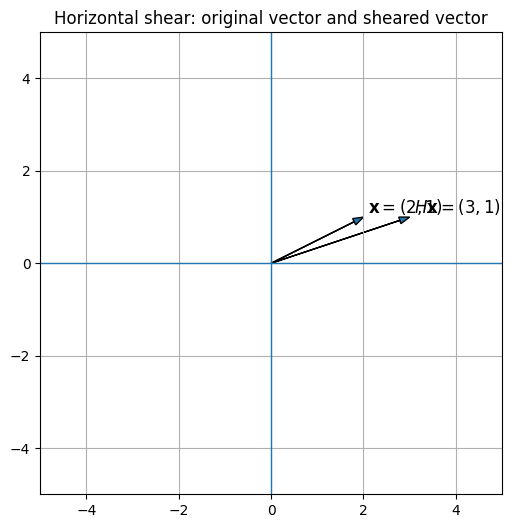

In [31]:
import numpy as np
import matplotlib.pyplot as plt

H = np.array([[1, 1],
              [0, 1]])

x = np.array([2, 1])
Hx = H @ x

def draw_axes(ax, lim=5):
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.grid(True)

fig, ax = plt.subplots(figsize=(6,6))
draw_axes(ax)

# original vector
ax.arrow(0, 0, x[0], x[1], head_width=0.15, length_includes_head=True)
ax.text(x[0]+0.1, x[1]+0.1, r'$\mathbf{x}=(2,1)$', fontsize=12)

# sheared vector
ax.arrow(0, 0, Hx[0], Hx[1], head_width=0.15, length_includes_head=True)
ax.text(Hx[0]+0.1, Hx[1]+0.1, r'$H\mathbf{x}=(3,1)$', fontsize=12)

ax.set_title("Horizontal shear: original vector and sheared vector")
plt.show()

For our vector

$$
\mathbf x=
\begin{bmatrix}
2\\
1
\end{bmatrix},
$$

the shear gives

$$
H\mathbf x
=
\begin{bmatrix}
1&1\\
0&1
\end{bmatrix}
\begin{bmatrix}
2\\
1
\end{bmatrix}
=
\begin{bmatrix}
2+1\\
1
\end{bmatrix}
=
\begin{bmatrix}
3\\
1
\end{bmatrix}.
$$

So the point moves from

$$
(2,1)
\quad \text{to} \quad
(3,1).
$$

Notice that the \(y\)-coordinate stays the same, while the \(x\)-coordinate increases by \(1\).

### Step 2: What does the rotation do?

Now let us examine the rotation matrix

$$
Q=
\begin{bmatrix}
0&-1\\
1&0
\end{bmatrix}.
$$

For a general vector

$$
\begin{bmatrix}
x\\
y
\end{bmatrix},
$$

we get

$$
Q
\begin{bmatrix}
x\\
y
\end{bmatrix}
=
\begin{bmatrix}
0&-1\\
1&0
\end{bmatrix}
\begin{bmatrix}
x\\
y
\end{bmatrix}
=
\begin{bmatrix}
-y\\
x
\end{bmatrix}.
$$

Thus, \(Q\) rotates every vector by \(90^\circ\) counterclockwise.

<>:17: SyntaxWarning: invalid escape sequence '\c'
<>:17: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_4345/3531973046.py:17: SyntaxWarning: invalid escape sequence '\c'
  ax.set_title("Rotation by $90^\circ$: original vector and rotated vector")


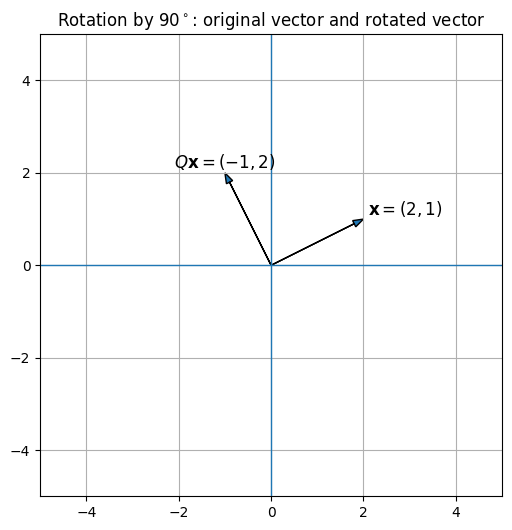

In [32]:
Q = np.array([[0, -1],
              [1,  0]])

Qx = Q @ x

fig, ax = plt.subplots(figsize=(6,6))
draw_axes(ax)

# original vector
ax.arrow(0, 0, x[0], x[1], head_width=0.15, length_includes_head=True)
ax.text(x[0]+0.1, x[1]+0.1, r'$\mathbf{x}=(2,1)$', fontsize=12)

# rotated vector
ax.arrow(0, 0, Qx[0], Qx[1], head_width=0.15, length_includes_head=True)
ax.text(Qx[0]-1.1, Qx[1]+0.1, r'$Q\mathbf{x}=(-1,2)$', fontsize=12)

ax.set_title("Rotation by $90^\circ$: original vector and rotated vector")
plt.show()

For the same vector

$$
\mathbf x=
\begin{bmatrix}
2\\
1
\end{bmatrix},
$$

rotation gives

$$
Q\mathbf x
=
\begin{bmatrix}
0&-1\\
1&0
\end{bmatrix}
\begin{bmatrix}
2\\
1
\end{bmatrix}
=
\begin{bmatrix}
-1\\
2
\end{bmatrix}.
$$

So if we rotate \(\mathbf x\) directly, it moves from

$$
(2,1)
\quad \text{to} \quad
(-1,2).
$$

### Step 3: Shear first, then rotate

Now we perform the transformations in sequence.

Because the shear happens first, we start with

$$
H\mathbf x=
\begin{bmatrix}
3\\
1
\end{bmatrix}.
$$

Then we rotate this new vector:

$$
Q(H\mathbf x)
=
Q
\begin{bmatrix}
3\\
1
\end{bmatrix}
=
\begin{bmatrix}
-1\\
3
\end{bmatrix}.
$$

So the overall effect is

$$
\mathbf x=(2,1)
\;\longrightarrow\;
H\mathbf x=(3,1)
\;\longrightarrow\;
QH\mathbf x=(-1,3).
$$

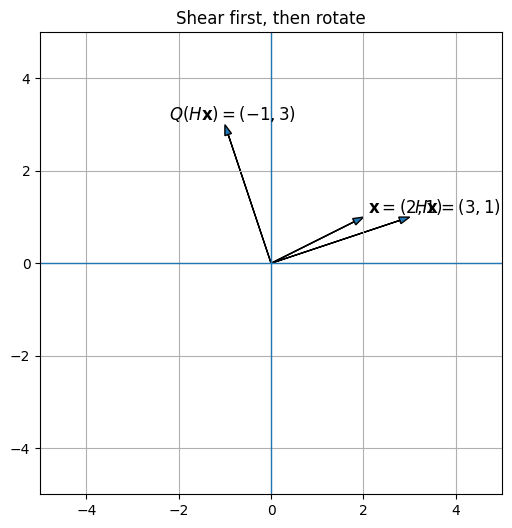

In [33]:
QHx = Q @ Hx

fig, ax = plt.subplots(figsize=(6,6))
draw_axes(ax)

# original vector
ax.arrow(0, 0, x[0], x[1], head_width=0.15, length_includes_head=True)
ax.text(x[0]+0.1, x[1]+0.1, r'$\mathbf{x}=(2,1)$', fontsize=12)

# sheared vector
ax.arrow(0, 0, Hx[0], Hx[1], head_width=0.15, length_includes_head=True)
ax.text(Hx[0]+0.1, Hx[1]+0.1, r'$H\mathbf{x}=(3,1)$', fontsize=12)

# final rotated-after-shear vector
ax.arrow(0, 0, QHx[0], QHx[1], head_width=0.15, length_includes_head=True)
ax.text(QHx[0]-1.2, QHx[1]+0.1, r'$Q(H\mathbf{x})=(-1,3)$', fontsize=12)

ax.set_title("Shear first, then rotate")
plt.show()

### Step 4: Combine the two transformations into one matrix

When the shear happens first and the rotation happens second, the combined matrix is

$$
QH.
$$

Let us compute it:

$$
QH
=
\begin{bmatrix}
0&-1\\
1&0
\end{bmatrix}
\begin{bmatrix}
1&1\\
0&1
\end{bmatrix}
=
\begin{bmatrix}
0&-1\\
1&1
\end{bmatrix}.
$$

Now apply this single matrix directly to \(\mathbf x\):

$$
(QH)\mathbf x
=
\begin{bmatrix}
0&-1\\
1&1
\end{bmatrix}
\begin{bmatrix}
2\\
1
\end{bmatrix}
=
\begin{bmatrix}
-1\\
3
\end{bmatrix}.
$$

This matches the two-step process exactly:

$$
(QH)\mathbf x = Q(H\mathbf x).
$$

### Important idea

This example shows why matrix multiplication represents composition of transformations.

- \(H\) acts first;
- \(Q\) acts second;
- therefore the combined matrix is \(QH\).

So the order of multiplication reflects the order of action from right to left:

$$
Q(H\mathbf x)=(QH)\mathbf x.
$$

This is a very important point:

> The matrix closest to the vector acts first.

In [34]:
H = sp.Matrix([[1,1],[0,1]])
Q = sp.Matrix([[0,-1],[1,0]])
x = sp.Matrix([2,1])
show_matrix(Q*H,'QH')
show_vector(H*x,r'H\mathbf x')
show_vector(Q*H*x,r'QH\mathbf x')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

⎡-1⎤
⎢  ⎥
⎣3 ⎦

> **Definition: Inverse Linear Transformation**
>
> Suppose $T:V\to W$ is linear. A linear transformation
>
> $$
> T^{-1}:W\to V
> $$
>
> is an inverse of $T$ if
>
> $$
> T^{-1}(T(\mathbf v))=\mathbf v
> $$
>
> for every $\mathbf v\in V$, and
>
> $$
> T(T^{-1}(\mathbf w))=\mathbf w
> $$
>
> for every $\mathbf w\in W$.

> **Theorem: Invertible linear transformation and invertible matrix**
>
> For
>
> $$
> T:\mathbb R^n\to\mathbb R^n
> $$
>
> with standard matrix $A$, the following are equivalent:
>
> 1. $T$ is invertible;
> 2. $T$ is an isomorphism;
> 3. $A$ is invertible.
>
> When these conditions hold,
>
> $$
> \boxed{[T^{-1}]=A^{-1}}.
> $$

### Proof of the matrix statement

Assume $A$ is invertible and define

$$
S(\mathbf y)=A^{-1}\mathbf y.
$$

Then

$$
S(T(\mathbf x))
=A^{-1}A\mathbf x
=\mathbf x,
$$

and

$$
T(S(\mathbf y))
=AA^{-1}\mathbf y
=\mathbf y.
$$

Thus $S=T^{-1}$.

Conversely, if $T^{-1}$ exists and has standard matrix $B$, then

$$
BA=I
$$

and

$$
AB=I.
$$

Therefore $A$ is invertible and

$$
B=A^{-1}.
$$

### Classroom Check: What does the inverse matrix mean geometrically?

Explain why $A^{-1}$ must undo every effect of $A$.

In [35]:
reveal_answer_key('6.3-inv','Reveal explanation')

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## Inverse transformation example

Let

$$
T:\mathbb R^2\to\mathbb R^2
$$

have standard matrix

$$
A=
\begin{bmatrix}
2&1\\
1&1
\end{bmatrix}.
$$

Since

$$
\det(A)=2(1)-1(1)=1\ne0,
$$

$A$ is invertible.

The inverse matrix is

$$
A^{-1}
=
\begin{bmatrix}
1&-1\\
-1&2
\end{bmatrix}.
$$

Therefore,

$$
T^{-1}(y_1,y_2)
=(y_1-y_2,-y_1+2y_2).
$$

In [36]:
A = sp.Matrix([[2,1],[1,1]])
Ainv = A.inv()
show_matrix(A,'A')
show_matrix(Ainv,r'A^{-1}')
show_matrix(Ainv*A,r'A^{-1}A')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

⎡1  0⎤
⎢    ⎥
⎣0  1⎦

## Matrices relative to nonstandard bases

Let

$$
B=\{\mathbf v_1,\ldots,\mathbf v_n\}
$$

be an ordered basis for the domain $V$, and let

$$
C=\{\mathbf w_1,\ldots,\mathbf w_m\}
$$

be an ordered basis for the codomain $W$.

We want a matrix that accepts $B$-coordinates and produces $C$-coordinates:

$$
\boxed{
[T(\mathbf v)]_C
=[T]_{C\leftarrow B}[\mathbf v]_B.
}
$$

The columns are

$$
\boxed{
[T]_{C\leftarrow B}
=
\begin{bmatrix}
[T(\mathbf v_1)]_C&\cdots&[T(\mathbf v_n)]_C
\end{bmatrix}.
}
$$

### Why do the columns have this form?

Suppose

$$
B=\{\mathbf v_1,\mathbf v_2,\ldots,\mathbf v_n\}
$$

is a basis for the domain, and

$$
C=\{\mathbf w_1,\mathbf w_2,\ldots,\mathbf w_m\}
$$

is a basis for the codomain.

The matrix

$$
[T]_{C\leftarrow B}
$$

is defined so that

$$
[T(\mathbf x)]_C
=
[T]_{C\leftarrow B}[\mathbf x]_B.
$$

This means:

* the input vector is expressed using \(B\)-coordinates;
* the matrix represents the transformation \(T\);
* the output is expressed using \(C\)-coordinates.

Now consider one of the basis vectors,

$$
\mathbf v_j.
$$

Because \($\mathbf v_j\$) is the \(j\)-th basis vector in \(B\),

$$
\mathbf v_j
=
0\mathbf v_1+\cdots+0\mathbf v_{j-1}
+1\mathbf v_j
+0\mathbf v_{j+1}+\cdots+0\mathbf v_n.
$$

Therefore,

$$
[\mathbf v_j]_B
=
\mathbf e_j,
$$

where

$$
\mathbf e_j
=
\begin{bmatrix}
0\\
\vdots\\
0\\
1\\
0\\
\vdots\\
0
\end{bmatrix}
$$

has a \(1\) in position \(j\) and zeros everywhere else.

Now apply the matrix representation:

$$
[T(\mathbf v_j)]_C
=
[T]_{C\leftarrow B}[\mathbf v_j]_B.
$$

Since

$$
[\mathbf v_j]_B=\mathbf e_j,
$$

we obtain

$$
[T(\mathbf v_j)]_C
=
[T]_{C\leftarrow B}\mathbf e_j.
$$

Why does multiplying by \($\mathbf e_j\$) select column \(j\)?

Suppose

$$
[T]_{C\leftarrow B}
=
\begin{bmatrix}
\vert & \vert & & \vert\\
\mathbf a_1 & \mathbf a_2 & \cdots & \mathbf a_n\\
\vert & \vert & & \vert
\end{bmatrix}.
$$

Then

$$
[T]_{C\leftarrow B}\mathbf e_j
=
0\mathbf a_1+\cdots+1\mathbf a_j+\cdots+0\mathbf a_n
=
\mathbf a_j.
$$

For example,

$$
\begin{bmatrix}
\vert & \vert & \vert\\
\mathbf a_1 & \mathbf a_2 & \mathbf a_3\\
\vert & \vert & \vert
\end{bmatrix}
\begin{bmatrix}
0\\
1\\
0
\end{bmatrix}
=
\mathbf a_2.
$$

Therefore,

$$
[T]_{C\leftarrow B}\mathbf e_j
=
\text{column }j\text{ of }[T]_{C\leftarrow B}.
$$

But we already know that

$$
[T]_{C\leftarrow B}\mathbf e_j
=
[T(\mathbf v_j)]_C.
$$

Hence,

$$
\boxed{
\text{column }j\text{ of }[T]_{C\leftarrow B}
=
[T(\mathbf v_j)]_C
}
$$

and therefore

$$
\boxed{
[T]_{C\leftarrow B}
=
\begin{bmatrix}
[T(\mathbf v_1)]_C
&
[T(\mathbf v_2)]_C
&
\cdots
&
[T(\mathbf v_n)]_C
\end{bmatrix}.
}
$$

### Main idea

Each column tells us where one basis vector goes under the transformation.

* **Column 1** records the image of the first basis vector:

$$
T(\mathbf v_1).
$$

* **Column 2** records the image of the second basis vector:

$$
T(\mathbf v_2).
$$

* Continuing in the same way,

* **Column \(j\)** records the image of the \(j\)-th basis vector:

$$
T(\mathbf v_j).
$$



The important point is that each transformed vector is written using the codomain basis \(C\).

So we can remember:

$$
\boxed{
\text{columns of }[T]_{C\leftarrow B}
=
\text{\(C\)-coordinates of the transformed \(B\)-basis vectors}.
}
$$


### Classroom Check: What is the input coordinate system and what is the output coordinate system?

For

$$
[T]_{C\leftarrow B},
$$

what type of coordinate vector goes into the matrix, and what type comes out?

In [37]:
reveal_answer_key('6.3-nonstd','Reveal explanation')

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## Nonstandard-basis example

Let

$$
T(x_1,x_2)=(x_1+x_2,2x_1-x_2).
$$

Use the domain basis

$$
B=\{(1,2),(-1,1)\}
$$

and codomain basis

$$
C=\{(1,0),(0,1)\}.
$$

First,

$$
T(1,2)=(3,0),
$$

so

$$
[T(1,2)]_C=
\begin{bmatrix}
3\\
0
\end{bmatrix}.
$$

Next,

$$
T(-1,1)=(0,-3),
$$

so

$$
[T(-1,1)]_C=
\begin{bmatrix}
0\\
-3
\end{bmatrix}.
$$

Therefore,

$$
\boxed{
[T]_{C\leftarrow B}
=
\begin{bmatrix}
3&0\\
0&-3
\end{bmatrix}.
}
$$


## Example: both the domain basis and codomain basis are nonstandard

Consider the same linear transformation

$$
T(x_1,x_2)=(x_1+x_2,\,2x_1-x_2).
$$

Use the domain basis

$$
B=\{\mathbf v_1,\mathbf v_2\}
=
\{(1,2),(-1,1)\},
$$

and now use the nonstandard codomain basis

$$
C=\{\mathbf w_1,\mathbf w_2\}
=
\{(1,1),(1,-1)\}.
$$

We want to find

$$
[T]_{C\leftarrow B}.
$$

Recall that the columns are

$$
[T]_{C\leftarrow B}
=
\begin{bmatrix}
[T(\mathbf v_1)]_C
&
[T(\mathbf v_2)]_C
\end{bmatrix}.
$$

So we first apply $T$ to each basis vector in $B$, and then express each output using the basis $C$.

---

### Step 1: Apply $T$ to the first basis vector

Since

$$
\mathbf v_1=(1,2),
$$

we have

$$
T(1,2)
=
(1+2,\,2(1)-2)
=
(3,0).
$$

Because $C$ is not the standard basis, we cannot immediately write

$$
[T(1,2)]_C=
\begin{bmatrix}
3\\
0
\end{bmatrix}.
$$

Instead, we must express $(3,0)$ as a linear combination of the vectors in $C$.

We want scalars $c_1$ and $c_2$ such that

$$
(3,0)
=
c_1(1,1)+c_2(1,-1).
$$

Comparing components gives

$$
\begin{cases}
c_1+c_2=3,\\
c_1-c_2=0.
\end{cases}
$$

Adding the equations,

$$
2c_1=3,
$$

so

$$
c_1=\frac32.
$$

Then

$$
c_2=\frac32.
$$

Therefore,

$$
(3,0)
=
\frac32(1,1)
+
\frac32(1,-1),
$$

and hence

$$
[T(\mathbf v_1)]_C
=
\begin{bmatrix}
\frac32\\
\frac32
\end{bmatrix}.
$$

---

### Step 2: Apply $T$ to the second basis vector

Since

$$
\mathbf v_2=(-1,1),
$$

we have

$$
T(-1,1)
=
(-1+1,\,2(-1)-1)
=
(0,-3).
$$

Again, we must express this vector using the basis $C$.

We want

$$
(0,-3)
=
c_1(1,1)+c_2(1,-1).
$$

Comparing components gives

$$
\begin{cases}
c_1+c_2=0,\\
c_1-c_2=-3.
\end{cases}
$$

Adding the equations,

$$
2c_1=-3,
$$

so

$$
c_1=-\frac32.
$$

Then

$$
c_2=\frac32.
$$

Therefore,

$$
(0,-3)
=
-\frac32(1,1)
+
\frac32(1,-1),
$$

so

$$
[T(\mathbf v_2)]_C
=
\begin{bmatrix}
-\frac32\\
\frac32
\end{bmatrix}.
$$

---

### Step 3: Form the matrix of the transformation

The coordinate vectors become the columns of the matrix:

$$
[T]_{C\leftarrow B}
=
\begin{bmatrix}
[T(\mathbf v_1)]_C
&
[T(\mathbf v_2)]_C
\end{bmatrix}.
$$

Therefore,

$$
\boxed{
[T]_{C\leftarrow B}
=
\begin{bmatrix}
\frac32 & -\frac32\\
\frac32 & \frac32
\end{bmatrix}.
}
$$

---

### Main idea

When constructing

$$
[T]_{C\leftarrow B},
$$

remember the two different roles of the bases:

$$
\boxed{
B\text{ tells us which input vectors to apply }T\text{ to.}
}
$$

$$
\boxed{
C\text{ tells us how to describe the output vectors.}
}
$$

If $C$ is the standard basis, the coordinates of $T(\mathbf v_j)$ can be read directly.

If $C$ is nonstandard, we must first rewrite each output as a linear combination of the basis vectors in $C$.



## Differential operator matrix

Consider

$$
D:P_2\to P_1,
$$

$$
D(p)=p'.
$$

Use the domain basis

$$
B=\{1,x,x^2\}
$$

and codomain basis

$$
C=\{1,x\}.
$$

We have

$$
D(1)=0,
$$

$$
D(x)=1,
$$

$$
D(x^2)=2x.
$$

Thus the coordinate columns are

$$
[D(1)]_C=
\begin{bmatrix}
0\\
0
\end{bmatrix},
$$

$$
[D(x)]_C=
\begin{bmatrix}
1\\
0
\end{bmatrix},
$$

$$
[D(x^2)]_C=
\begin{bmatrix}
0\\
2
\end{bmatrix}.
$$

Therefore,

$$
\boxed{
[D]_{C\leftarrow B}
=
\begin{bmatrix}
0&1&0\\
0&0&2
\end{bmatrix}.
}
$$

## Definitions and terminology

| Term | Meaning |
|---|---|
| Standard matrix | Matrix of a linear map between coordinate spaces using standard bases. |
| Composition | Applying one transformation after another. |
| Inverse transformation | Transformation that reverses another transformation. |
| Invertible transformation | Linear transformation possessing an inverse. |
| Matrix relative to bases | Matrix converting domain-basis coordinates to codomain-basis coordinates after applying $T$. |
| Domain basis | Ordered basis used to encode input coordinates. |
| Codomain basis | Ordered basis used to encode output coordinates. |

## Section 6.3 worksheet

Work each problem before revealing the instructor solution.

### Problem 1

Find the standard matrix of $T(x,y,z)=(x-2y,2x+y)$.

In [38]:
reveal_answer_key('6.3-w1','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 2

If $T_1$ has matrix $A_1$ and $T_2$ has matrix $A_2$, what is the standard matrix of $T_2\circ T_1$? Explain the order.

In [39]:
reveal_answer_key('6.3-w2','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 3

For $A=\begin{bmatrix}2&1\1&1\end{bmatrix}$, find the matrix of the inverse transformation.

In [40]:
reveal_answer_key('6.3-w3','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 4

Describe the procedure for constructing a matrix of $T:V	o W$ relative to a domain basis $B$ and codomain basis $C$.

In [41]:
reveal_answer_key('6.3-w4','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 5

Find the matrix of $D:P_2	o P_1$ relative to $B=\{1,x,x^2\}$ and $C=\{1,x\}$.

In [42]:
reveal_answer_key('6.3-w5','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 6

Explain algebraically why applying $T$ and then $T^{-1}$ returns the original vector.

In [43]:
reveal_answer_key('6.3-w6','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

# Section 6.4 - Transition Matrices and Similarity

## Learning objectives

Students should be able to:

- interpret a coordinate vector relative to an ordered basis;
- construct and use transition matrices between ordered bases;
- explain why the transition-matrix columns are coordinate vectors of basis elements;
- derive the formula $P_{C\leftarrow B}=M_C^{-1}M_B$;
- justify the Gauss-Jordan construction $[M_C\mid M_B]\to[I\mid P_{C\leftarrow B}]$;
- derive the similarity relation between two matrices representing the same linear transformation;
- use simple similarity invariants already available from earlier chapters;
- exploit a simpler representation matrix to compute powers.

## Coordinate vectors revisit

Let

$$
B=\{\mathbf b_1,\ldots,\mathbf b_n\}
$$

be an ordered basis for $V$.

If

$$
\mathbf x=x_1\mathbf b_1+\cdots+x_n\mathbf b_n,
$$

then the coordinate vector of $\mathbf x$ relative to $B$ is

$$
[\mathbf x]_B=
\begin{bmatrix}
x_1\\
\vdots\\
x_n
\end{bmatrix}.
$$

The vector $\mathbf x$ and the coordinate column $[\mathbf x]_B$ are related but are not the same object: $\mathbf x$ lives in $V$, while $[\mathbf x]_B$ is a coordinate representation in $\mathbb R^n$.

> **Definition: Transition Matrix**
>
> Let
>
> $$
> B=\{\mathbf b_1,\ldots,\mathbf b_n\}
> $$
>
> and
>
> $$
> C=\{\mathbf c_1,\ldots,\mathbf c_n\}
> $$
>
> be ordered bases for the same vector space $V$.
>
> The transition matrix
>
> $$
> P_{C\leftarrow B}
> $$
>
> converts $B$-coordinates into $C$-coordinates:
>
> $$
> \boxed{
> [\mathbf x]_C=P_{C\leftarrow B}[\mathbf x]_B.
> }
> $$
>
> Read the notation as **destination $\leftarrow$ source**:
>
> $$
> B\text{-coordinates}\longrightarrow C\text{-coordinates}.
> $$
>
> The vector itself does not change; only its coordinate description changes.

### Classroom Check: Read the arrow correctly

What does

$$
P_{C\leftarrow B}
$$

do to a coordinate vector?

In [44]:
reveal_answer_key('6.4-arrow','Reveal explanation')

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## Why are the columns $C$-coordinates of the $B$-basis vectors?

In basis $B$,

$$
[\mathbf b_1]_B=\mathbf e_1,
$$

$$
[\mathbf b_2]_B=\mathbf e_2,
$$

and so on.

Apply the transition matrix:

$$
[\mathbf b_j]_C
=P_{C\leftarrow B}[\mathbf b_j]_B
=P_{C\leftarrow B}\mathbf e_j.
$$

Multiplying a matrix by $\mathbf e_j$ selects column $j$. Therefore,

$$
\boxed{
P_{C\leftarrow B}
=
\begin{bmatrix}
[\mathbf b_1]_C&[\mathbf b_2]_C&\cdots&[\mathbf b_n]_C
\end{bmatrix}.
}
$$

So column $j$ tells us how the source-basis vector $\mathbf b_j$ is described using the destination basis $C$.

### Classroom Check: Why are the columns not $[\mathbf c_j]_B$?

Use the input-output direction of the matrix to explain which basis vectors belong in the columns.

In [45]:
reveal_answer_key('6.4-columns','Reveal explanation')

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## Basis matrices and the formula $P_{C\leftarrow B}=M_C^{-1}M_B$

When the basis vectors are written in standard coordinates, define the basis matrices

$$
M_B=
\begin{bmatrix}
\mathbf b_1&\cdots&\mathbf b_n
\end{bmatrix}
$$

and

$$
M_C=
\begin{bmatrix}
\mathbf c_1&\cdots&\mathbf c_n
\end{bmatrix}.
$$

For any vector $\mathbf x$,

$$
\mathbf x=M_B[\mathbf x]_B
$$

and

$$
\mathbf x=M_C[\mathbf x]_C.
$$

Therefore,

$$
M_C[\mathbf x]_C=M_B[\mathbf x]_B.
$$

Multiply by $M_C^{-1}$:

$$
[\mathbf x]_C=M_C^{-1}M_B[\mathbf x]_B.
$$

Comparing this with

$$
[\mathbf x]_C=P_{C\leftarrow B}[\mathbf x]_B,
$$

we obtain

$$
\boxed{
P_{C\leftarrow B}=M_C^{-1}M_B.
}
$$

## Coordinate-conversion example

Let

$$
B=\{(1,1),(1,-1)\}
$$

and

$$
C=\{(1,0),(1,1)\}.
$$

Then

$$
M_B=
\begin{bmatrix}
1&1\\
1&-1
\end{bmatrix}
$$

and

$$
M_C=
\begin{bmatrix}
1&1\\
0&1
\end{bmatrix}.
$$

Because

$$
M_C^{-1}=
\begin{bmatrix}
1&-1\\
0&1
\end{bmatrix},
$$

we obtain

$$
P_{C\leftarrow B}
=M_C^{-1}M_B
=
\begin{bmatrix}
0&2\\
1&-1
\end{bmatrix}.
$$

If

$$
[\mathbf x]_B=
\begin{bmatrix}
3\\
2
\end{bmatrix},
$$

then

$$
[\mathbf x]_C
=
\begin{bmatrix}
0&2\\
1&-1
\end{bmatrix}
\begin{bmatrix}
3\\
2
\end{bmatrix}
=
\begin{bmatrix}
4\\
1
\end{bmatrix}.
$$

In [46]:
MB = sp.Matrix([[1,1],[1,-1]])
MC = sp.Matrix([[1,1],[0,1]])
P = MC.inv()*MB
show_matrix(P,r'P_{C\leftarrow B}')
xb = sp.Matrix([3,2])
show_vector(P*xb,r'[\mathbf x]_C')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

⎡4⎤
⎢ ⎥
⎣1⎦

## Gauss-Jordan construction of the transition matrix

Instead of explicitly computing $M_C^{-1}$ first, row reduce

$$
[M_C\mid M_B].
$$

The key result is

$$
\boxed{
[M_C\mid M_B]
\longrightarrow
[I\mid P_{C\leftarrow B}].
}
$$

This is not a trick; it is the same inverse-matrix mechanism used in Chapter 2.

### Proof of the Gauss-Jordan construction

A sequence of row operations is equivalent to left multiplication by an invertible matrix $E$:

$$
[M_C\mid M_B]
\longrightarrow
[EM_C\mid EM_B].
$$

We choose the row operations so that

$$
EM_C=I.
$$

Therefore,

$$
E=M_C^{-1}.
$$

The same row operations transform the right block into

$$
EM_B=M_C^{-1}M_B.
$$

But

$$
M_C^{-1}M_B=P_{C\leftarrow B}.
$$

Hence

$$
\boxed{
[M_C\mid M_B]
\longrightarrow
[I\mid P_{C\leftarrow B}].
}
$$

A second interpretation is that the augmented matrix solves the systems

$$
M_C[\mathbf b_j]_C=\mathbf b_j
$$

for all source-basis vectors simultaneously.

### Classroom Check: What matrix are the row operations effectively multiplying by?

If the left block becomes $I$, identify the matrix $E$ represented by the row operations.

In [47]:
reveal_answer_key('6.4-gj','Reveal proof idea')

ToggleButton(value=False, button_style='info', description='Reveal proof idea', icon='eye', layout=Layout(widt…

## Reversing the coordinate direction

The reverse transition matrix satisfies

$$
[\mathbf x]_B=P_{B\leftarrow C}[\mathbf x]_C.
$$

Because converting from $B$ to $C$ and then back to $B$ must return the original coordinate vector,

$$
P_{B\leftarrow C}P_{C\leftarrow B}=I.
$$

Therefore,

$$
\boxed{
P_{B\leftarrow C}=(P_{C\leftarrow B})^{-1}.
}
$$

## The same linear transformation in two different bases

Let $T:V\to V$ be linear. Suppose

$$
A_B
$$

is the matrix of $T$ relative to basis $B$, and

$$
A_C
$$

is the matrix relative to basis $C$.

Start with $[\mathbf x]_C$.

1. Convert from $C$-coordinates to $B$-coordinates:

$$
[\mathbf x]_B=P_{B\leftarrow C}[\mathbf x]_C.
$$

2. Apply the transformation in basis $B$:

$$
[T(\mathbf x)]_B=A_B[\mathbf x]_B.
$$

3. Convert the output back to $C$-coordinates:

$$
[T(\mathbf x)]_C=P_{C\leftarrow B}[T(\mathbf x)]_B.
$$

Combining the three steps,

$$
[T(\mathbf x)]_C
=P_{C\leftarrow B}A_BP_{B\leftarrow C}[\mathbf x]_C.
$$

Therefore,

$$
\boxed{
A_C=P_{C\leftarrow B}A_BP_{B\leftarrow C}.
}
$$

Since the two transition matrices are inverses, the two matrices are related by similarity.

> **Definition: Similar Matrices**
>
> Square matrices $A$ and $A'$ are **similar** if there exists an invertible matrix $P$ such that
>
> $$
> \boxed{A'=P^{-1}AP}.
> $$
>
> Similar matrices can represent the **same linear transformation** using different ordered bases.

### Classroom Check: Derive the similarity formula rather than memorize it

Explain the three coordinate steps hidden inside the product that changes a representation matrix from one basis to another.

In [48]:
reveal_answer_key('6.4-sim','Reveal derivation')

ToggleButton(value=False, button_style='info', description='Reveal derivation', icon='eye', layout=Layout(widt…

## Similarity is an equivalence relation

Similarity has three basic properties.

**Reflexive:**

$$
A=I^{-1}AI,
$$

so $A$ is similar to itself.

**Symmetric:** If

$$
B=P^{-1}AP,
$$

then

$$
A=PBP^{-1},
$$

so $A$ is similar to $B$ whenever $B$ is similar to $A$.

**Transitive:** If

$$
B=P^{-1}AP
$$

and

$$
C=Q^{-1}BQ,
$$

then

$$
C=(PQ)^{-1}A(PQ).
$$

Thus similarity groups matrices that represent the same linear structure under different coordinates.


## A simpler representation in a well-chosen basis

Consider the linear transformation whose matrix in the standard basis is

$$
A=
\begin{bmatrix}
2&1\\
1&2
\end{bmatrix}.
$$

Thus, if a vector is written in standard coordinates, then

$$
[T(\mathbf x)]_{\text{standard}}
=
A[\mathbf x]_{\text{standard}}.
$$

Now choose the nonstandard basis

$$
B=\{\mathbf v_1,\mathbf v_2\}
=
\{(1,1),(1,-1)\}.
$$

We want to answer the following question:

> What does the same linear transformation look like when vectors are described using the basis \(B\) instead of the standard basis?

---

### Step 1: Build the change-of-coordinates matrix

The basis vectors are

$$
\mathbf v_1=
\begin{bmatrix}
1\\
1
\end{bmatrix},
\qquad
\mathbf v_2=
\begin{bmatrix}
1\\
-1
\end{bmatrix}.
$$

Place these basis vectors into the columns of a matrix:

$$
P=
\begin{bmatrix}
1&1\\
1&-1
\end{bmatrix}.
$$

The matrix \(P\) converts \(B\)-coordinates into standard coordinates.

If

$$
[\mathbf x]_B
=
\begin{bmatrix}
c_1\\
c_2
\end{bmatrix},
$$

then

$$
\mathbf x
=
c_1\mathbf v_1+c_2\mathbf v_2.
$$

Therefore,

$$
[\mathbf x]_{\text{standard}}
=
P[\mathbf x]_B.
$$

So we can remember:

$$
\boxed{
P:\quad B\text{-coordinates}\longrightarrow \text{standard coordinates}.
}
$$

---

### Step 2: What does \(P^{-1}\) do?

Since \(P\) converts from \(B\)-coordinates to standard coordinates, its inverse performs the reverse conversion:

$$
\boxed{
P^{-1}:\quad
\text{standard coordinates}\longrightarrow B\text{-coordinates}.
}
$$

For this example,

$$
P^{-1}
=
\frac12
\begin{bmatrix}
1&1\\
1&-1
\end{bmatrix}.
$$

Thus,

$$
[\mathbf x]_B
=
P^{-1}[\mathbf x]_{\text{standard}}.
$$

---

### Step 3: Why is the new matrix \(P^{-1}AP\)?

Suppose we begin with a vector described in \(B\)-coordinates:

$$
[\mathbf x]_B.
$$

To apply the transformation \(T\), whose matrix \(A\) is written in standard coordinates, we must perform three steps.

#### First: convert from \(B\)-coordinates to standard coordinates

$$
[\mathbf x]_B
\overset{P}{\longrightarrow}
[\mathbf x]_{\text{standard}}.
$$

That is,

$$
[\mathbf x]_{\text{standard}}
=
P[\mathbf x]_B.
$$

#### Second: apply the transformation

$$
[T(\mathbf x)]_{\text{standard}}
=
A[\mathbf x]_{\text{standard}}.
$$

Substituting the previous expression gives

$$
[T(\mathbf x)]_{\text{standard}}
=
AP[\mathbf x]_B.
$$

#### Third: convert the output back to \(B\)-coordinates

Apply \(P^{-1}\):

$$
[T(\mathbf x)]_B
=
P^{-1}[T(\mathbf x)]_{\text{standard}}.
$$

Therefore,

$$
[T(\mathbf x)]_B
=
P^{-1}AP[\mathbf x]_B.
$$

Hence the matrix of the transformation relative to the basis \(B\) is

$$
\boxed{
A_B=P^{-1}AP.
}
$$

The order can be visualized as

$$
[\mathbf x]_B
\overset{P}{\longrightarrow}
[\mathbf x]_{\text{standard}}
\overset{A}{\longrightarrow}
[T(\mathbf x)]_{\text{standard}}
\overset{P^{-1}}{\longrightarrow}
[T(\mathbf x)]_B.
$$

Remember that matrix multiplication acts from right to left, so the combined matrix is

$$
P^{-1}AP.
$$

---

### Step 4: Compute \(A_B\)

We have

$$
A_B
=
P^{-1}AP.
$$

First compute

$$
AP
=
\begin{bmatrix}
2&1\\
1&2
\end{bmatrix}
\begin{bmatrix}
1&1\\
1&-1
\end{bmatrix}.
$$

This gives

$$
AP
=
\begin{bmatrix}
3&1\\
3&-1
\end{bmatrix}.
$$

Now multiply by \(P^{-1}\):

$$
A_B
=
\frac12
\begin{bmatrix}
1&1\\
1&-1
\end{bmatrix}
\begin{bmatrix}
3&1\\
3&-1
\end{bmatrix}.
$$

Therefore,

$$
A_B
=
\frac12
\begin{bmatrix}
6&0\\
0&2
\end{bmatrix}
=
\boxed{
\begin{bmatrix}
3&0\\
0&1
\end{bmatrix}
}.
$$

---

## Why does this matrix become so simple?

We can understand the result directly by looking at what \(T\) does to the basis vectors.

Recall

$$
\mathbf v_1=
\begin{bmatrix}
1\\
1
\end{bmatrix}.
$$

Apply \(A\):

$$
T(\mathbf v_1)
=
A\mathbf v_1
=
\begin{bmatrix}
2&1\\
1&2
\end{bmatrix}
\begin{bmatrix}
1\\
1
\end{bmatrix}.
$$

Thus,

$$
T(\mathbf v_1)
=
\begin{bmatrix}
3\\
3
\end{bmatrix}.
$$

But

$$
\begin{bmatrix}
3\\
3
\end{bmatrix}
=
3
\begin{bmatrix}
1\\
1
\end{bmatrix}
=
3\mathbf v_1.
$$

Therefore,

$$
T(\mathbf v_1)=3\mathbf v_1.
$$

Now comes an important coordinate distinction.

In the standard basis,

$$
T(\mathbf v_1)
=
\begin{bmatrix}
3\\
3
\end{bmatrix}.
$$

But relative to the basis \(B\),

$$
T(\mathbf v_1)
=
3\mathbf v_1+0\mathbf v_2.
$$

The coefficients are therefore \(3\) and \(0\). Hence,

$$
\boxed{
[T(\mathbf v_1)]_B
=
\begin{bmatrix}
3\\
0
\end{bmatrix}.
}
$$

This does **not** mean that

$$
T(\mathbf v_1)
=
\begin{bmatrix}
3\\
0
\end{bmatrix}
$$

in standard coordinates.

Instead,

$$
\begin{bmatrix}
3\\
0
\end{bmatrix}
$$

records how much of each basis vector in \(B\) is needed:

$$
3\mathbf v_1+0\mathbf v_2.
$$

---

### Now consider the second basis vector

Recall

$$
\mathbf v_2=
\begin{bmatrix}
1\\
-1
\end{bmatrix}.
$$

Then

$$
T(\mathbf v_2)
=
A\mathbf v_2
=
\begin{bmatrix}
2&1\\
1&2
\end{bmatrix}
\begin{bmatrix}
1\\
-1
\end{bmatrix}.
$$

Therefore,

$$
T(\mathbf v_2)
=
\begin{bmatrix}
1\\
-1
\end{bmatrix}
=
\mathbf v_2.
$$

So

$$
T(\mathbf v_2)
=
0\mathbf v_1+1\mathbf v_2.
$$

Therefore,

$$
\boxed{
[T(\mathbf v_2)]_B
=
\begin{bmatrix}
0\\
1
\end{bmatrix}.
}
$$

---

### Step 5: Build the matrix directly from the transformed basis vectors

The columns of the matrix relative to \(B\) are

$$
[T(\mathbf v_1)]_B
\qquad\text{and}\qquad
[T(\mathbf v_2)]_B.
$$

Therefore,

$$
A_B
=
\begin{bmatrix}
[T(\mathbf v_1)]_B
&
[T(\mathbf v_2)]_B
\end{bmatrix}.
$$

Substituting the coordinate vectors,

$$
A_B
=
\begin{bmatrix}
3&0\\
0&1
\end{bmatrix}.
$$

Thus we obtain the same result as before:

$$
\boxed{
A_B=P^{-1}AP
=
\begin{bmatrix}
3&0\\
0&1
\end{bmatrix}.
}
$$

---

## Main idea

The matrix

$$
A=
\begin{bmatrix}
2&1\\
1&2
\end{bmatrix}
$$

looks like it mixes the two standard coordinate directions.

However, the basis

$$
B=\{\mathbf v_1,\mathbf v_2\}
$$

is especially well chosen because the transformation does not mix these two directions:

$$
T(\mathbf v_1)=3\mathbf v_1,
$$

and

$$
T(\mathbf v_2)=1\mathbf v_2.
$$

So in the basis \(B\), the transformation simply says:

- multiply the first basis direction by \(3\);
- multiply the second basis direction by \(1\).

That is why its matrix becomes

$$
\boxed{
A_B=
\begin{bmatrix}
3&0\\
0&1
\end{bmatrix}.
}
$$

> **Important distinction:** A vector itself does not change when we change bases. What changes is the coordinate vector used to describe it.

> This is a preview of an important idea developed more systematically in Chapter 7. For now, the key lesson is that a carefully chosen basis can make the matrix representation of a linear transformation much simpler.



In [49]:
A = sp.Matrix([[2,1],[1,2]])
P = sp.Matrix([[1,1],[1,-1]])
D = sp.simplify(P.inv()*A*P)
show_matrix(D,r'P^{-1}AP')

<IPython.core.display.Math object>

⎡3  0⎤
⎢    ⎥
⎣0  1⎦


## Quantities preserved under similarity

Suppose

$$
A'=P^{-1}AP,
$$

where $P$ is invertible.

Although $A$ and $A'$ may look very different, they represent the same linear transformation with respect to different bases. Because of this, several important quantities remain unchanged.

---

### Determinant

Using the multiplicative property of determinants,

$$
\det(A')
=
\det(P^{-1})\det(A)\det(P).
$$

Since

$$
\det(P^{-1})=\frac{1}{\det(P)},
$$

we obtain

$$
\boxed{
\det(A')=\det(A).
}
$$

---

### Rank

Multiplying a matrix on the left or right by an invertible matrix does not change its rank. Therefore,

$$
\boxed{
\operatorname{rank}(A')=\operatorname{rank}(A).
}
$$

---

### A new quantity: trace

For a square matrix

$$
A=[a_{ij}],
$$

the **trace** of $A$ is the sum of its diagonal entries:

$$
\boxed{
\operatorname{tr}(A)
=
a_{11}+a_{22}+\cdots+a_{nn}.
}
$$

For example,

$$
A=
\begin{bmatrix}
2&1\\
1&2
\end{bmatrix}
$$

has trace

$$
\operatorname{tr}(A)=2+2=4.
$$

One useful property of trace is

$$
\operatorname{tr}(XY)=\operatorname{tr}(YX)
$$

whenever both products are defined and square.

Therefore,

$$
\begin{aligned}
\operatorname{tr}(A')
&=
\operatorname{tr}(P^{-1}AP)\\
&=
\operatorname{tr}(APP^{-1})\\
&=
\operatorname{tr}(A).
\end{aligned}
$$

Thus,

$$
\boxed{
\operatorname{tr}(A')=\operatorname{tr}(A).
}
$$

---

### Check with our example

Recall

$$
A=
\begin{bmatrix}
2&1\\
1&2
\end{bmatrix},
\qquad
A_B=
\begin{bmatrix}
3&0\\
0&1
\end{bmatrix}.
$$

For the trace,

$$
\operatorname{tr}(A)=2+2=4,
$$

while

$$
\operatorname{tr}(A_B)=3+1=4.
$$

Therefore,

$$
\boxed{
\operatorname{tr}(A)=\operatorname{tr}(A_B)=4.
}
$$

For the determinant,

$$
\det(A)
=
2(2)-1(1)
=
3,
$$

and

$$
\det(A_B)
=
3(1)
=
3.
$$

Therefore,

$$
\boxed{
\det(A)=\det(A_B)=3.
}
$$

The matrices look different, but these quantities remain unchanged because the matrices are related by a change of basis.



### Classroom Check: Why should basis-independent quantities agree?

A basis change changes the coordinate description, not the underlying transformation. Which of determinant, rank, and trace remain the same in the example?

In [50]:
reveal_answer_key('6.4-invar','Reveal proof summary')

ToggleButton(value=False, button_style='info', description='Reveal proof summary', icon='eye', layout=Layout(w…


## Computing powers through a simpler similar matrix

Recall from the previous example that

$$
A=
\begin{bmatrix}
2&1\\
1&2
\end{bmatrix},
$$

and that using the basis

$$
B=\{(1,1),(1,-1)\},
$$

we obtained the simpler matrix

$$
D=
\begin{bmatrix}
3&0\\
0&1
\end{bmatrix}.
$$

The change-of-basis matrix is

$$
P=
\begin{bmatrix}
1&1\\
1&-1
\end{bmatrix},
$$

with

$$
P^{-1}
=
\frac12
\begin{bmatrix}
1&1\\
1&-1
\end{bmatrix}.
$$

We previously found

$$
D=P^{-1}AP.
$$

Multiplying by $P$ on the left and $P^{-1}$ on the right gives the equivalent relation

$$
\boxed{
A=PDP^{-1}.
}
$$

This form is especially useful when we want to compute powers of $A$.

---

### Computing $A^2$

Since

$$
A=PDP^{-1},
$$

we have

$$
A^2
=
(PDP^{-1})(PDP^{-1}).
$$

Using associativity,

$$
A^2
=
PD(P^{-1}P)DP^{-1}.
$$

Since

$$
P^{-1}P=I,
$$

we get

$$
A^2
=
PDIDP^{-1}
=
PD^2P^{-1}.
$$

The middle factors $P^{-1}P$ cancel.

---

### Computing higher powers

The same cancellation continues for higher powers:

$$
A^3
=
(PDP^{-1})(PDP^{-1})(PDP^{-1})
=
PD^3P^{-1}.
$$

Therefore, for any positive integer $n$,

$$
\boxed{
A^n=PD^nP^{-1}.
}
$$

The advantage is that powers of the diagonal matrix $D$ are very easy to compute.

Since

$$
D=
\begin{bmatrix}
3&0\\
0&1
\end{bmatrix},
$$

we have

$$
D^n=
\begin{bmatrix}
3^n&0\\
0&1^n
\end{bmatrix}
=
\begin{bmatrix}
3^n&0\\
0&1
\end{bmatrix}.
$$

Thus,

$$
A^n
=
P
\begin{bmatrix}
3^n&0\\
0&1
\end{bmatrix}
P^{-1}.
$$

Substituting $P$ and $P^{-1}$,

$$
A^n
=
\begin{bmatrix}
1&1\\
1&-1
\end{bmatrix}
\begin{bmatrix}
3^n&0\\
0&1
\end{bmatrix}
\frac12
\begin{bmatrix}
1&1\\
1&-1
\end{bmatrix}.
$$

First,

$$
P D^n
=
\begin{bmatrix}
3^n&1\\
3^n&-1
\end{bmatrix}.
$$

Therefore,

$$
A^n
=
\frac12
\begin{bmatrix}
3^n&1\\
3^n&-1
\end{bmatrix}
\begin{bmatrix}
1&1\\
1&-1
\end{bmatrix}.
$$

Multiplying gives

$$
\boxed{
A^n
=
\frac12
\begin{bmatrix}
3^n+1&3^n-1\\
3^n-1&3^n+1
\end{bmatrix}.
}
$$

---

### Example: compute $A^5$

Since

$$
3^5=243,
$$

we obtain

$$
A^5
=
\frac12
\begin{bmatrix}
244&242\\
242&244
\end{bmatrix}.
$$

Therefore,

$$
\boxed{
A^5=
\begin{bmatrix}
122&121\\
121&122
\end{bmatrix}.
}
$$

Instead of multiplying

$$
A=
\begin{bmatrix}
2&1\\
1&2
\end{bmatrix}
$$

by itself five times, we compute the much simpler power $D^5$ and then change coordinates back.



In [51]:
n = sp.symbols('n', integer=True, nonnegative=True)
A = sp.Matrix([[2,1],[1,2]])
print('A^5 by direct computation:')
display(A**5)

A^5 by direct computation:


⎡122  121⎤
⎢        ⎥
⎣121  122⎦

## Definitions and terminology

| Term | Meaning |
|---|---|
| Coordinate vector | Ordered coefficients of a vector relative to an ordered basis. |
| Basis matrix | Matrix whose columns are basis vectors in a common coordinate system. |
| Transition matrix | Matrix converting coordinates from one ordered basis to another. |
| $P_{C\leftarrow B}$ | Converts $B$-coordinates into $C$-coordinates. |
| Similar matrices | Matrices related by $A'=P^{-1}AP$. |
| Similarity invariant | Quantity unchanged by similarity, such as determinant, rank, or trace. |
| Diagonal representation | A representation matrix with zero off-diagonal entries in a suitable basis. |

## Section 6.4 worksheet

Work each problem before revealing the instructor solution.

### Problem 1

For $B=\{(1,1),(1,-1)\}$ and $C=\{(1,0),(1,1)\}$, find $P_{C\leftarrow B}$.

In [52]:
reveal_answer_key('6.4-w1','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 2

Convert $[\mathbf x]_B=(3,2)$ to $C$-coordinates.

In [53]:
reveal_answer_key('6.4-w2','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 3

For $A=\begin{bmatrix}2&1\1&2\end{bmatrix}$ and $P=\begin{bmatrix}1&1\1&-1\end{bmatrix}$, compute $P^{-1}AP$.

In [54]:
reveal_answer_key('6.4-w3','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 4

Verify that $A$ and $P^{-1}AP$ have the same trace and determinant.

In [55]:
reveal_answer_key('6.4-w4','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 5

Use the diagonal representation to compute $A^5$.

In [56]:
reveal_answer_key('6.4-w5','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 6

Explain why the order of vectors in a basis matters for a transition matrix.

In [57]:
reveal_answer_key('6.4-w6','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

# Section 6.5 - Applications of Linear Transformations

## Learning objectives

Students should be able to:

- construct matrices for reflections, scalings, shears, and rotations from basis images;
- transform points and planar figures by matrix multiplication;
- compose geometric transformations and interpret the order;
- connect determinant with area scaling and orientation information from Chapter 3;
- derive the planar rotation matrix;
- rotate three-dimensional points about coordinate axes;
- use computational visualization to explore parameterized transformations.

## Geometry from the images of the standard basis

A planar linear transformation is completely determined by what it does to

$$
\mathbf e_1=(1,0)
$$

and

$$
\mathbf e_2=(0,1).
$$

The standard matrix is

$$
A=
\begin{bmatrix}
T(\mathbf e_1)&T(\mathbf e_2)
\end{bmatrix}.
$$

This provides a geometric way to remember transformation matrices: **the columns show where the coordinate axes go**.

### Classroom Check: Why can two transformed basis vectors determine the image of every point?

Use

$$
(x,y)=x\mathbf e_1+y\mathbf e_2.
$$

In [58]:
reveal_answer_key('6.5-basisimg','Reveal explanation')

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## Standard planar transformations

### Reflection across the $y$-axis

$$
T(x,y)=(-x,y),
$$

so

$$
R_y=
\begin{bmatrix}
-1&0\\
0&1
\end{bmatrix}.
$$

### Reflection across the $x$-axis

$$
R_x=
\begin{bmatrix}
1&0\\
0&-1
\end{bmatrix}.
$$

### Reflection across the line $y=x$

$$
T(x,y)=(y,x),
$$

so

$$
R_{y=x}=
\begin{bmatrix}
0&1\\
1&0
\end{bmatrix}.
$$

### Horizontal scaling

$$
S_x(k)=
\begin{bmatrix}
k&0\\
0&1
\end{bmatrix}.
$$

### Vertical scaling

$$
S_y(k)=
\begin{bmatrix}
1&0\\
0&k
\end{bmatrix}.
$$

### Horizontal shear

$$
H_x(k)=
\begin{bmatrix}
1&k\\
0&1
\end{bmatrix}.
$$

### Vertical shear

$$
H_y(k)=
\begin{bmatrix}
1&0\\
k&1
\end{bmatrix}.
$$

## Badminton-court shear

Model a small rectangular court outline by the vertices

$$
(0,0),
$$

$$
(6,0),
$$

$$
(6,3),
$$

$$
(0,3).
$$

Apply

$$
H_x(1/2)=
\begin{bmatrix}
1&1/2\\
0&1
\end{bmatrix}.
$$

A point $(x,y)$ becomes

$$
(x+y/2,y).
$$

Thus the lower edge remains fixed because $y=0$, while the upper edge shifts right by $3/2$ units because $y=3$.

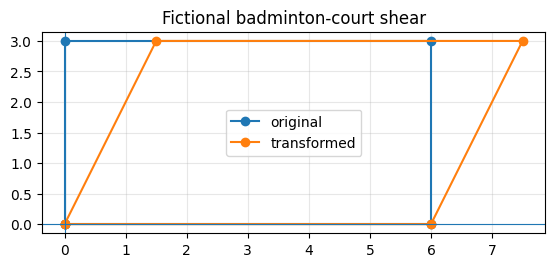

In [59]:
H = np.array([[1,.5],[0,1]], dtype=float)
court = np.array([[0,0],[6,0],[6,3],[0,3]], dtype=float)
plot_linear_map_2d(H, court, 'Fictional badminton-court shear')

## Determinant and area scaling

For a planar linear transformation with standard matrix $A$,

$$
\boxed{
\text{area scale factor}=|\det(A)|.
}
$$

For the horizontal shear

$$
H_x(k)=
\begin{bmatrix}
1&k\\
0&1
\end{bmatrix},
$$

we have

$$
\det(H_x(k))=1.
$$

Therefore shear changes shape but preserves area.

For

$$
S=
\begin{bmatrix}
2&0\\
0&1/2
\end{bmatrix},
$$

we also have

$$
\det(S)=1.
$$

The first coordinate doubles while the second is halved, and the two effects cancel in area.

### Classroom Check: Why can a shear change angles but preserve area?

Connect the geometry to the determinant.

In [60]:
reveal_answer_key('6.5-shear','Reveal explanation')

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## Deriving the planar rotation matrix

Consider a counterclockwise rotation through angle $\theta$.

The vector

$$
\mathbf e_1=(1,0)
$$

rotates to

$$
T(\mathbf e_1)=(\cos\theta,\sin\theta).
$$

The vector

$$
\mathbf e_2=(0,1)
$$

is already $90^\circ$ ahead of $\mathbf e_1$, so after rotation it becomes

$$
T(\mathbf e_2)=(-\sin\theta,\cos\theta).
$$

Using these images as columns gives

$$
\boxed{
Q(\theta)=
\begin{bmatrix}
\cos\theta&-\sin\theta\\
\sin\theta&\cos\theta
\end{bmatrix}.
}
$$

## Rotation of a travel marker

Rotate

$$
(2,0)
$$

counterclockwise by $30^\circ$.

Since

$$
Q(30^\circ)=
\begin{bmatrix}
\sqrt3/2&-1/2\\
1/2&\sqrt3/2
\end{bmatrix},
$$

we have

$$
Q(30^\circ)
\begin{bmatrix}
2\\
0
\end{bmatrix}
=
\begin{bmatrix}
\sqrt3\\
1
\end{bmatrix}.
$$

The length remains $2$:

$$
\sqrt{(\sqrt3)^2+1^2}=2.
$$

## Why rotations preserve length

The columns of $Q(\theta)$ are orthonormal, so

$$
Q(\theta)^TQ(\theta)=I.
$$

Therefore,

$$
\|Q(\theta)\mathbf x\|^2
=(Q\mathbf x)^T(Q\mathbf x)
=\mathbf x^TQ^TQ\mathbf x
=\mathbf x^T\mathbf x
=\|\mathbf x\|^2.
$$

Also,

$$
\det(Q(\theta))=1,
$$

so rotations preserve area and orientation.

### Classroom Check: What matrix identity guarantees length preservation?

Which product involving $Q^T$ and $Q$ reduces the norm calculation to the original norm?

In [61]:
reveal_answer_key('6.5-rot','Reveal explanation')

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## Composition and order: stretch then rotate

Suppose a fictional pennant is first stretched horizontally by a factor of $2$ and then rotated $90^\circ$ counterclockwise.

The scaling matrix is

$$
S=
\begin{bmatrix}
2&0\\
0&1
\end{bmatrix},
$$

and the rotation matrix is

$$
Q=
\begin{bmatrix}
0&-1\\
1&0
\end{bmatrix}.
$$

Because the stretch occurs first, the combined transformation is

$$
QS
=
\begin{bmatrix}
0&-1\\
2&0
\end{bmatrix}.
$$

If the order is reversed, then

$$
SQ
=
\begin{bmatrix}
0&-2\\
1&0
\end{bmatrix}.
$$

The matrices differ, so the geometric results differ.

### Classroom Check: Which matrix goes on the right?

If transformation $A$ happens first and transformation $B$ happens second, what is the combined matrix?

In [62]:
reveal_answer_key('6.5-order','Reveal explanation')

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## Three-dimensional rotation about the $z$-axis

A counterclockwise rotation about the $z$-axis leaves the $z$-coordinate unchanged and rotates the $xy$-coordinates:

$$
\boxed{
R_z(\theta)=
\begin{bmatrix}
\cos\theta&-\sin\theta&0\\
\sin\theta&\cos\theta&0\\
0&0&1
\end{bmatrix}.
}
$$

At

$$
\theta=90^\circ,
$$

we obtain

$$
R_z(90^\circ)(1,2,3)=(-2,1,3).
$$

Only the $xy$-coordinates rotate; the height remains unchanged.

## Rotations about the other coordinate axes

Using the right-hand-rule convention, the standard matrices are

$$
R_x(\theta)=
\begin{bmatrix}
1&0&0\\
0&\cos\theta&-\sin\theta\\
0&\sin\theta&\cos\theta
\end{bmatrix},
$$

and

$$
R_y(\theta)=
\begin{bmatrix}
\cos\theta&0&\sin\theta\\
0&1&0\\
-\sin\theta&0&\cos\theta
\end{bmatrix}.
$$

Each matrix leaves the coordinate along its rotation axis unchanged and rotates the perpendicular coordinate plane.

## Interactive rotation explorer

The following cell rotates an ellipse through angles from $0^\circ$ to $90^\circ$. It imports the widget objects inside the cell so it remains robust even if an earlier widget-import cell was not executed.

In [63]:
# Interactive rotation explorer. This cell is self-contained.
def rotated_ellipse(theta_degrees=45):
    theta = np.deg2rad(theta_degrees)
    t = np.linspace(0, 2*np.pi, 400)
    base = np.vstack([3*np.cos(t), 1.5*np.sin(t)])
    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])
    pts = R @ base

    plt.figure(figsize=(6,6))
    plt.plot(pts[0], pts[1])
    plt.axhline(0, linewidth=.8)
    plt.axvline(0, linewidth=.8)
    plt.grid(alpha=.3)
    plt.axis('equal')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Rotated ellipse: {theta_degrees} degrees')
    plt.show()

try:
    from ipywidgets import interact, IntSlider
    interact(
        rotated_ellipse,
        theta_degrees=IntSlider(min=0, max=90, step=5, value=45, description='Angle:')
    )
except ImportError:
    print('Interactive widgets are unavailable. Showing the 45-degree example.')
    rotated_ellipse(45)

interactive(children=(IntSlider(value=45, description='Angle:', max=90, step=5), Output()), _dom_classes=('wid…

## Definitions and terminology

| Term | Meaning |
|---|---|
| Reflection | Mirror transformation across a line or axis. |
| Expansion | Scaling that increases distance in a direction. |
| Contraction | Scaling that decreases distance in a direction. |
| Shear | Transformation sliding parallel layers by proportional amounts. |
| Rotation | Rigid turn about the origin or an axis. |
| Area scale factor | $|\det(A)|$ for a planar linear transformation. |
| Orthogonal matrix | Matrix $Q$ satisfying $Q^TQ=I$. |
| Rotation matrix | Orthogonal matrix with determinant $1$ representing a rigid rotation. |
| Right-hand rule | Convention determining positive three-dimensional rotation direction. |

## Section 6.5 worksheet

Work each problem before revealing the instructor solution.

### Problem 1

Identify the transformations represented by $\begin{bmatrix}-1&0\0&1\end{bmatrix}$ and $\begin{bmatrix}1&2\0&1\end{bmatrix}$.

In [64]:
reveal_answer_key('6.5-w1','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 2

Reflect the point $(3,-2)$ across the line $y=x$.

In [65]:
reveal_answer_key('6.5-w2','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 3

Apply the horizontal shear $H(1/2)$ to the triangle with vertices $(0,0)$, $(4,0)$, and $(0,2)$.

In [66]:
reveal_answer_key('6.5-w3','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 4

Rotate $(2,0)$ counterclockwise by $30^\circ$.

In [67]:
reveal_answer_key('6.5-w4','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 5

Find the matrix for a horizontal stretch by $2$ followed by a $90^\circ$ counterclockwise rotation.

In [68]:
reveal_answer_key('6.5-w5','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 6

Rotate $(1,2,3)$ counterclockwise by $90^\circ$ about the $z$-axis.

In [69]:
reveal_answer_key('6.5-w6','Reveal solution')

ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

# Section 6.6 - Kronecker Product and Structured Matrices

## Learning objectives

Students should be able to:

- construct the Kronecker product of two small matrices;
- determine the dimensions of a Kronecker product;
- use basic Kronecker-product identities;
- recognize how Kronecker products create large structured matrices from smaller ones.

> **Purpose of this session:** The Kronecker product is an enrichment topic. The goal is not to develop tensor-product theory, but to give students a practical matrix construction that appears frequently in numerical linear algebra, scientific computing, data science, and later advanced courses.


## From a scalar entry to an entire matrix block

For ordinary matrix multiplication, an entry of one matrix is multiplied by entries of another matrix and then summed.

The **Kronecker product** does something different: each scalar entry of one matrix is replaced by a scaled copy of the entire second matrix.

The symbol is

$$
\boxed{A\otimes B}.
$$

The symbol $\otimes$ is read as **Kronecker product** when we are working with matrices.


> **Definition: Kronecker Product**
>
> Let
>
> $$
> A=[a_{ij}]\in\mathbb R^{m\times n}
> $$
>
> and let
>
> $$
> B\in\mathbb R^{p\times q}.
> $$
>
> The **Kronecker product** of $A$ and $B$ is the block matrix
>
> $$
> \boxed{
> A\otimes B=
> \begin{bmatrix}
> a_{11}B&a_{12}B&\cdots&a_{1n}B\\
> a_{21}B&a_{22}B&\cdots&a_{2n}B\\
> \vdots&\vdots&&\vdots\\
> a_{m1}B&a_{m2}B&\cdots&a_{mn}B
> \end{bmatrix}.
> }
> $$
>
> Each entry $a_{ij}$ of $A$ becomes the block $a_{ij}B$.


## Dimension rule

If

$$
A\in\mathbb R^{m\times n}
$$

and

$$
B\in\mathbb R^{p\times q},
$$

then

$$
\boxed{
A\otimes B\in\mathbb R^{mp\times nq}.
}
$$

The reason is simple: $A$ has $m$ block rows and $n$ block columns, while each copy of $B$ contributes $p$ ordinary rows and $q$ ordinary columns.

Unlike ordinary matrix multiplication, the Kronecker product can be formed for **any two matrices**; no inner-dimension matching condition is required.


### Classroom Check: Determine the size before computing

Suppose

$$
A\in\mathbb R^{2\times3}
$$

and

$$
B\in\mathbb R^{4\times2}.
$$

What is the size of $A\otimes B$?


In [70]:
reveal_answer_key('6.6-check','Reveal answer')


ToggleButton(value=False, button_style='info', description='Reveal answer', icon='eye', layout=Layout(width='1…

## Worked Example: Constructing a Kronecker product

Let

$$
A=
\begin{bmatrix}
1&2\\
3&4
\end{bmatrix},
$$

and

$$
B=
\begin{bmatrix}
0&5\\
6&7
\end{bmatrix}.
$$

By definition,

$$
A\otimes B
=
\begin{bmatrix}
1B&2B\\
3B&4B
\end{bmatrix}.
$$

Compute the four blocks:

$$
1B=
\begin{bmatrix}
0&5\\
6&7
\end{bmatrix},
$$

$$
2B=
\begin{bmatrix}
0&10\\
12&14
\end{bmatrix},
$$

$$
3B=
\begin{bmatrix}
0&15\\
18&21
\end{bmatrix},
$$

and

$$
4B=
\begin{bmatrix}
0&20\\
24&28
\end{bmatrix}.
$$

Therefore,

$$
\boxed{
A\otimes B=
\begin{bmatrix}
0&5&0&10\\
6&7&12&14\\
0&15&0&20\\
18&21&24&28
\end{bmatrix}.
}
$$

A $2\times2$ matrix Kronecker-multiplied by another $2\times2$ matrix produces a $4\times4$ matrix.


In [71]:
# NumPy verification of the worked example
A_kron = np.array([[1, 2],
                   [3, 4]])
B_kron = np.array([[0, 5],
                   [6, 7]])

print("A kron B =")
print(np.kron(A_kron, B_kron))


A kron B =
[[ 0  5  0 10]
 [ 6  7 12 14]
 [ 0 15  0 20]
 [18 21 24 28]]


## Kronecker product of vectors

The same construction works for column vectors. If

$$
\mathbf u=
\begin{bmatrix}
u_1\\u_2
\end{bmatrix}
$$

and

$$
\mathbf v=
\begin{bmatrix}
v_1\\v_2\\v_3
\end{bmatrix},
$$

then

$$
\boxed{
\mathbf u\otimes\mathbf v
=
\begin{bmatrix}
u_1\mathbf v\\u_2\mathbf v
\end{bmatrix}
=
\begin{bmatrix}
u_1v_1\\u_1v_2\\u_1v_3\\u_2v_1\\u_2v_2\\u_2v_3
\end{bmatrix}.
}
$$

For example,

$$
\begin{bmatrix}2\\3\end{bmatrix}
\otimes
\begin{bmatrix}1\\-1\end{bmatrix}
=
\begin{bmatrix}2\\-2\\3\\-3\end{bmatrix}.
$$


## Useful algebraic properties

For matrices of compatible sizes,

$$
(A+C)\otimes B=A\otimes B+C\otimes B,
$$

$$
A\otimes(B+D)=A\otimes B+A\otimes D,
$$

and

$$
(cA)\otimes B=c(A\otimes B)=A\otimes(cB).
$$

Transpose behaves naturally:

$$
\boxed{(A\otimes B)^T=A^T\otimes B^T.}
$$

The most useful multiplication identity is the **mixed-product property**:

$$
\boxed{
(A\otimes B)(C\otimes D)=(AC)\otimes(BD),
}
$$

provided the ordinary products $AC$ and $BD$ are defined.

If $A$ and $B$ are invertible, then

$$
\boxed{
(A\otimes B)^{-1}=A^{-1}\otimes B^{-1}.
}
$$


## Why the mixed-product property works

Think of the Kronecker product as a structured block matrix. The block in position $(i,j)$ of $A\otimes B$ is

$$
a_{ij}B.
$$

When block-matrix multiplication is carried out, the scalar coefficients from $A$ and $C$ combine exactly as they do in $AC$, while the matrix factors $B$ and $D$ combine as $BD$.

That is why the two structures separate cleanly:

$$
(A\otimes B)(C\otimes D)
=(AC)\otimes(BD).
$$

This identity is one reason Kronecker products are useful for very large structured systems.


## Application: Repeating the same transformation

Suppose a matrix $A$ represents a transformation that must be applied independently to three groups of variables.

Instead of writing a large block matrix manually, use

$$
I_3\otimes A.
$$

Because

$$
I_3=
\begin{bmatrix}
1&0&0\\
0&1&0\\
0&0&1
\end{bmatrix},
$$

we obtain

$$
\boxed{
I_3\otimes A=
\begin{bmatrix}
A&0&0\\
0&A&0\\
0&0&A
\end{bmatrix}.
}
$$

So $I_3\otimes A$ means: **apply the same matrix $A$ independently to three blocks of variables**.

This compact notation is common in numerical linear algebra, multidimensional models, network systems, and scientific computing.


## Kronecker product versus direct sum

The symbols look similar, but the constructions are different.

The matrix direct sum is

$$
\boxed{
A\oplus B=
\begin{bmatrix}
A&0\\
0&B
\end{bmatrix}.
}
$$

It places $A$ and $B$ in separate diagonal blocks.

By contrast,

$$
A\otimes B
$$

replaces **every scalar entry of $A$** by a scaled copy of $B$.

A useful memory aid is:

$$
\boxed{
\oplus:\text{ combine independent blocks}
}
$$

$$
\boxed{
\otimes:\text{ build repeated scaled block structure}.
}
$$


## Looking ahead: one more reason Kronecker products matter

In Chapter 7, after eigenvalues and eigenvectors have been introduced, we can prove an additional useful fact:

if

$$
A\mathbf x=\lambda\mathbf x
$$

and

$$
B\mathbf y=\mu\mathbf y,
$$

then

$$
\mathbf x\otimes\mathbf y
$$

is an eigenvector of $A\otimes B$ with eigenvalue

$$
\lambda\mu.
$$

For now, the main Chapter 6 idea is the **block construction** and the way it represents structured linear transformations.


## Section 6.6 terminology

| Term | Meaning |
|---|---|
| Kronecker product | The block matrix $A\otimes B$ obtained by replacing each entry $a_{ij}$ of $A$ with $a_{ij}B$. |
| Dimension rule | If $A$ is $m\times n$ and $B$ is $p\times q$, then $A\otimes B$ is $mp\times nq$. |
| Mixed-product property | $(A\otimes B)(C\otimes D)=(AC)\otimes(BD)$ when the ordinary products are defined. |
| Direct sum | $A\oplus B$ places $A$ and $B$ in separate diagonal blocks. |
| Structured matrix | A large matrix built from a repeated or organized pattern of smaller matrices. |


## Section 6.6 worksheet

Work each problem before revealing the instructor solution.


### Problem 1

Let

$$
A=
\begin{bmatrix}
1&2\\
0&-1
\end{bmatrix}
$$

and

$$
B=
\begin{bmatrix}
1&0\\
3&2
\end{bmatrix}.
$$

Compute $A\otimes B$.


In [72]:
reveal_answer_key('6.6-w1','Reveal solution')


ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 2

Describe the block structure of

$$
I_3\otimes A.
$$

What transformation does this matrix represent conceptually?


In [73]:
reveal_answer_key('6.6-w2','Reveal solution')


ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

### Problem 3

Explain the difference between

$$
A\oplus B
$$

and

$$
A\otimes B.
$$


In [74]:
reveal_answer_key('6.6-w3','Reveal solution')


ToggleButton(value=False, button_style='info', description='Reveal solution', icon='eye', layout=Layout(width=…

# Chapter 6 synthesis

A linear transformation can be studied from several mutually reinforcing viewpoints:

$$
\boxed{
\text{formula}
\longleftrightarrow
\text{basis images}
\longleftrightarrow
\text{matrix}
\longleftrightarrow
\text{kernel and range}
\longleftrightarrow
\text{geometry}.
}
$$

## Core structural connections

For a matrix transformation

$$
T(\mathbf x)=A\mathbf x,
$$

we have

$$
\boxed{\ker(T)=N(A)},
$$

and

$$
\boxed{\operatorname{range}(T)=\operatorname{Col}(A)}.
$$

Rank-nullity gives

$$
\boxed{
\operatorname{rank}(T)+\operatorname{nullity}(T)=\dim(\text{domain}).
}
$$

A linear transformation is one-to-one exactly when

$$
\boxed{\ker(T)=\{\mathbf0\}}.
$$

A linear transformation is onto a finite-dimensional codomain exactly when

$$
\boxed{\operatorname{rank}(T)=\dim(\text{codomain})}.
$$

The standard matrix is built from basis images:

$$
\boxed{
A=
\begin{bmatrix}
T(\mathbf e_1)&\cdots&T(\mathbf e_n)
\end{bmatrix}.
}
$$

Composition corresponds to matrix multiplication in reverse application order:

$$
\boxed{[T_2\circ T_1]=[T_2][T_1]}.
$$

Coordinate conversion is governed by transition matrices:

$$
\boxed{
[\mathbf x]_C=P_{C\leftarrow B}[\mathbf x]_B.
}
$$

Changing basis changes the matrix representation, not the underlying transformation. Similarity is the algebraic language for this change of coordinates.

Finally, geometric transformations make the matrix visible: columns tell where basis directions move, determinant tells area scaling, and composition tells how geometric operations combine.

## Looking ahead

Chapter 7 will develop a systematic method for finding special directions in which a transformation acts by simple scaling. The diagonal representation example in Section 6.4 is a preview of that idea, but Chapter 6 requires only the basis-change machinery developed here.

The Kronecker-product eigenvalue relationship previewed in Section 6.6 will also become available once eigenvalues and eigenvectors have been developed.
